Setup, Universe Definitions & Shared Functions

This cell locks the experimental protocol for all five universes.
The core idea is simple: run the **same framework** on five different
asset universes. Only the ticker list changes — everything else is fixed.
That is what makes the cross-universe comparison scientifically valid.

---

### Why Five Universes?

One universe proves the idea. Five universes prove it generalises.
Each universe tests a different dimension of robustness:

| Universe | What It Tests |
|---|---|
| U1 — US Large-Cap Stocks | Base case (existing paper) |
| U2 — European Country ETFs | Geographic + monetary policy variation |
| U3 — Asia-Pacific ETFs | Emerging market, higher volatility |
| U4 — US Sector ETFs | Sector rotation, zero selection bias |
| U5 — Multi-Asset ETFs | Cross-asset class (equity + bond + commodity) |

---

### Key Formulas

**Composite Instability Index (Definition 1):**

$$I_t = \frac{1}{3}\left(z(\sigma_t) + z(\rho_t) + z(\delta_t)\right)$$

- $\sigma_t$ = cross-sectional mean rolling volatility
- $\rho_t$ = mean pairwise rolling correlation
- $\delta_t = \|\hat{\Sigma}_t - \hat{\Sigma}_{t-1}\|_F$ = covariance drift

$z(\cdot)$ is Z-scored to the **pre-2020 training period only** —
the index cannot see the events it is meant to detect.

**Regime Operator (Definition 2):**

$$\mathcal{R}(I_t) = \begin{cases} \text{Equal Weight} & I_t > \theta_H \\ \text{Shrunk MV} & I_t \leq \theta_H \end{cases}$$

Binary, deterministic, fully auditable — every allocation decision
traces to one number compared against one threshold.

**James-Stein Shrinkage:**

$$\hat{\mu}_{JS} = \bar{\mu} + SF \cdot (\hat{\mu} - \bar{\mu}), 
\quad SF = \max\!\left(0,\ 1 - \frac{p-2}{n\,\|\hat{\mu}-\bar{\mu}\|^2}\right)$$

With large $n$ (2,515 training days), $SF \to 0$ — sample mean is trusted.
With small $n$, shrinkage pulls estimates toward the grand mean.

**Ledoit-Wolf Covariance Shrinkage:**

$$\hat{\Sigma}_{LW} = (1-\alpha)\hat{\Sigma} + \alpha\,\bar{\sigma}^2 I,
\quad \alpha = 0.0054 \text{ (analytically optimal)}$$

In [10]:
# ================================================================
# MULTI-UNIVERSE SUPERVISORY GOVERNANCE FRAMEWORK
# Cell 1 — Setup, Universe Definitions, Shared Functions
# ================================================================

import numpy as np
import pandas as pd
import yfinance as yf
import cvxpy as cp
from sklearn.covariance import LedoitWolf
from scipy.stats import ttest_rel, wilcoxon, jarque_bera
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8")
os.makedirs("universe_results", exist_ok=True)

# ── Locked parameters — never change across universes ───────
START_DATE   = "2010-01-01"
END_DATE     = "2024-12-31"
TRAIN_CUTOFF = "2019-12-31"
INST_WINDOW  = 60
THETA_H      = 1.00
LAMBDA_0     = 3.0
TC_BPS       = 10
TRAIN_WINDOW = 2 * 252   # 2-year estimation window
TEST_WINDOW  = 3 * 21    # 3-month test window

MODELS = ["static", "equal", "shrunk", "regime", "minvar"]
COLORS = {"static":"#1f77b4","equal":"#2ca02c",
          "shrunk":"#d62728","regime":"#9467bd","minvar":"#8c6d31"}
LABELS = {"static":"Static MV (Baseline)","equal":"Equal Weight (1/N)",
          "shrunk":"MV + JS+LW Shrinkage",
          "regime":"Regime Switch (Proposed)","minvar":"Min-Variance (LW)"}

STRESS_EVENTS = {
    "EU Debt Crisis": ("2010-05-01", "2012-12-31"),
    "China Crash":    ("2015-06-01", "2016-02-29"),
    "COVID Shock":    ("2020-02-01", "2020-12-31"),
    "Fed Rate Hikes": ("2022-01-01", "2022-12-31"),
}

# ── Five universes ───────────────────────────────────────────
UNIVERSES = {

    "U1_US_LargeCap": {
        "label": "US Large-Cap Equities",
        "region": "United States",
        "asset_type": "Individual Stocks",
        "start": "2010-01-01",
        "tickers": [
            "AAPL","MSFT","GOOGL","AMZN",      # Technology
            "JPM","BAC","GS","MS",             # Financial
            "XOM","CVX","COP",                 # Energy
            "JNJ","PFE","UNH",                 # Healthcare
            "PG","KO","PEP",                   # Consumer Staples
            "CAT","BA",                        # Industrial
        ],
    },

    "U2_European_ETFs": {
        "label": "European Country ETFs",
        "region": "Europe",
        "asset_type": "iShares MSCI Country ETF",
        "start": "2010-01-01",
        # EDEN replaced by ENOR (Norway); EWC replaced by EPOL (Poland)
        "tickers": [
            "EWG","EWU","EWQ","EWI",           # DE, UK, FR, IT
            "EWP","EWN","EWD","EWL",           # ES, NL, SE, CH
            "EWK","EWO","ENOR","EPOL",         # BE, AT, NO, PL
        ],
    },

    "U3_AsiaPacific_ETFs": {
        "label": "Asia-Pacific Country ETFs",
        "region": "Asia-Pacific",
        "asset_type": "iShares MSCI Country ETF",
        "start": "2012-01-01",   # INDA available from Feb 2012
        # EWZ (Brazil) replaced by AAXJ (Asia ex-Japan)
        "tickers": [
            "EWJ","EWH","EWA","EWY",           # JP, HK, AU, KR
            "EWT","INDA","FXI","EWM",          # TW, IN, CN, MY
            "EWS","AAXJ",                      # SG, Asia ex-JP
        ],
    },

    "U4_US_Sectors": {
        "label": "US Sector ETFs (SPDR)",
        "region": "United States",
        "asset_type": "SPDR Select Sector ETF",
        "start": "2010-01-01",
        # XLRE (2015) and XLC (2018) excluded — insufficient history
        "tickers": [
            "XLK","XLF","XLE","XLV",           # Tech, Financial, Energy, Health
            "XLP","XLY","XLI","XLB","XLU",     # Staples, Discr, Indus, Mat, Util
        ],
    },

    "U5_MultiAsset": {
        "label": "Multi-Asset Class ETFs",
        "region": "Global",
        "asset_type": "Multi-Asset ETF",
        "start": "2010-01-01",
        "tickers": [
            "SPY","EFA","EEM",                 # Equity: US, Intl, EM
            "AGG","IEF","TIP","HYG",           # Bonds: Agg, Treasury, TIPS, HY
            "GLD","VNQ","GSG",                 # Real Assets: Gold, REIT, Cmdty
        ],
    },
}

# ================================================================
# SHARED FUNCTIONS
# ================================================================

def fetch_universe(key):
    """Fetch, clean, return log returns + missing ticker list."""
    u       = UNIVERSES[key]
    raw     = yf.download(u["tickers"], start=u["start"],
                          end=END_DATE, progress=False)
    if isinstance(raw.columns, pd.MultiIndex):
        col    = "Adj Close" if "Adj Close" in raw.columns.levels[0] else "Close"
        prices = raw.xs(col, level=0, axis=1)
    else:
        prices = raw
    prices  = prices[[t for t in u["tickers"] if t in prices.columns]]
    prices  = prices.dropna(how="all").ffill().bfill().dropna()
    returns = np.log(prices / prices.shift(1)).dropna()
    missing = [t for t in u["tickers"] if t not in returns.columns]
    return returns, missing


def build_instability_index(returns):
    """
    Composite Instability Index — Definition 1.
    I_t = (z_vol + z_corr + z_drift) / 3
    Z-scored to pre-2020 training period only.
    """
    # Component 1: cross-sectional rolling volatility
    vol = returns.rolling(INST_WINDOW).std().mean(axis=1).dropna()

    # Component 2: mean pairwise rolling correlation
    corr_vals = []
    for i in range(INST_WINDOW, len(returns)):
        w  = returns.iloc[i - INST_WINDOW:i]
        cm = w.corr().values
        corr_vals.append(cm[np.triu_indices_from(cm, k=1)].mean())
    avg_corr = pd.Series(corr_vals, index=returns.index[INST_WINDOW:])

    # Component 3: covariance matrix drift (Frobenius norm)
    drift_vals = []
    for i in range(INST_WINDOW + 1, len(returns)):
        c1 = returns.iloc[i - INST_WINDOW:i].cov().values
        c0 = returns.iloc[i - INST_WINDOW - 1:i - 1].cov().values
        drift_vals.append(np.linalg.norm(c1 - c0, ord="fro"))
    cov_drift = pd.Series(drift_vals, index=returns.index[INST_WINDOW + 1:])

    # Align
    idx = vol.index.intersection(avg_corr.index).intersection(cov_drift.index)
    v, c, d = vol[idx], avg_corr[idx], cov_drift[idx]

    # Z-score to training period only
    def z(s):
        base = s[s.index <= TRAIN_CUTOFF]
        return (s - base.mean()) / (base.std() + 1e-10)

    instability = (z(v) + z(c) + z(d)) / 3.0
    components  = pd.DataFrame({
        "instability_index": instability,
        "vol_z": z(v), "corr_z": z(c), "drift_z": z(d),
        "volatility": v, "correlation": c, "cov_drift": d,
    })
    return instability, components


def shrink_mu(mu, n_obs):
    """James-Stein shrinkage: pulls μ toward grand mean."""
    p, mu_bar = len(mu), mu.mean()
    diff, norm_sq = mu - mu_bar, ((mu - mu_bar)**2).sum()
    if norm_sq == 0: return mu.copy()
    sf = float(np.clip(1 - (p - 2) / (n_obs * norm_sq), 0, 1))
    return mu_bar + sf * diff


def shrink_cov(train):
    """Ledoit-Wolf analytical covariance shrinkage."""
    lw = LedoitWolf().fit(train.values)
    return pd.DataFrame(lw.covariance_,
                        index=train.columns, columns=train.columns)


def mv_opt(mu, Sigma, lam):
    """MV: max μᵀw - (λ/2)wᵀΣw  s.t. 1ᵀw=1, w≥0"""
    n, w = len(mu), cp.Variable(len(mu))
    prob = cp.Problem(
        cp.Maximize(mu.values @ w - (lam/2)*cp.quad_form(w, Sigma.values)),
        [cp.sum(w)==1, w>=0])
    for solver in [cp.SCS, cp.OSQP]:
        try:
            prob.solve(solver=solver, verbose=False)
            if w.value is not None and "optimal" in prob.status:
                wt = np.clip(w.value, 0, None)
                return pd.Series(wt/wt.sum(), index=mu.index)
        except: pass
    return pd.Series(np.ones(n)/n, index=mu.index)


def minvar_opt(Sigma):
    """Min-variance: min wᵀΣw  s.t. 1ᵀw=1, w≥0"""
    n, w = len(Sigma), cp.Variable(len(Sigma))
    prob = cp.Problem(cp.Minimize(cp.quad_form(w, Sigma.values)),
                      [cp.sum(w)==1, w>=0])
    for solver in [cp.SCS, cp.OSQP]:
        try:
            prob.solve(solver=solver, verbose=False)
            if w.value is not None and "optimal" in prob.status:
                wt = np.clip(w.value, 0, None)
                return pd.Series(wt/wt.sum(), index=Sigma.index)
        except: pass
    return pd.Series(np.ones(n)/n, index=Sigma.index)


def compute_metrics(test_ret, weights, prev_weights):
    """Performance + governance metrics for one window."""
    port = (test_ret * weights).sum(axis=1)
    if prev_weights is not None:
        tc   = np.abs(weights - prev_weights).sum() * TC_BPS / 10000
        port = port - tc / len(port)

    ann_ret = port.mean() * 252
    ann_vol = port.std()  * np.sqrt(252)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else 0.0
    cum     = (1 + port).cumprod()
    dd      = ((cum - cum.cummax()) / cum.cummax()).min()
    calmar  = ann_ret / abs(dd) if dd < 0 else 0.0
    w       = weights.values
    hhi     = (w**2).sum()
    gs      = float(np.abs(weights - prev_weights).sum()) \
              if prev_weights is not None else np.nan
    return dict(ann_ret=ann_ret, ann_vol=ann_vol, sharpe=sharpe,
                dd=dd, calmar=calmar, hhi=hhi,
                effn=1/hhi if hhi>0 else 0.0, gs=gs)


def run_backtest(returns, instability):
    """51-window rolling OOS backtest — same for every universe."""
    results, prev_w = [], {m: None for m in MODELS}
    n = len(returns.columns)

    for idx, start in enumerate(
            range(TRAIN_WINDOW, len(returns)-TEST_WINDOW, TEST_WINDOW)):
        train = returns.iloc[start-TRAIN_WINDOW:start]
        test  = returns.iloc[start:start+TEST_WINDOW]
        date  = returns.index[start]
        if date not in instability.index: continue

        inst   = instability.loc[date]
        mu_js  = shrink_mu(train.mean(), len(train))
        sig_lw = shrink_cov(train)
        ew     = pd.Series(np.full(n, 1/n), index=train.columns)

        wmap = {
            "static": mv_opt(train.mean(), train.cov(), LAMBDA_0),
            "equal":  ew,
            "shrunk": mv_opt(mu_js, sig_lw, LAMBDA_0),
            "minvar": minvar_opt(sig_lw),
        }
        wmap["regime"] = ew.copy() if inst > THETA_H else wmap["shrunk"].copy()
        regime_label   = "equal_weight" if inst > THETA_H else "shrunk_mv"

        row = {"date":date, "instability":inst,
               "regime":regime_label, "window_idx":idx}
        for m, w in wmap.items():
            wa = w.reindex(test.columns, fill_value=0)
            wa = wa / wa.sum()
            for k, v in compute_metrics(test, wa, prev_w[m]).items():
                row[f"{k}_{m}"] = v
            prev_w[m] = wa
        results.append(row)

    df = pd.DataFrame(results)
    df["date"] = pd.to_datetime(df["date"])
    return df


def sig_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    if p < 0.10:  return "†"
    return "n.s."


# ── Verification ─────────────────────────────────────────────
print("="*60)
print("CELL 1 COMPLETE — EXPERIMENTAL PROTOCOL LOCKED")
print("="*60)
print(f"\n{'Universe':<28} {'N':>4}  {'Region':<22} {'Start'}")
print("-"*60)
for k, u in UNIVERSES.items():
    print(f"  {u['label']:<26} {len(u['tickers']):>4}  "
          f"{u['region']:<22} {u['start']}")
print(f"\nFixed: θ_H={THETA_H} | λ={LAMBDA_0} | TC={TC_BPS}bps | "
      f"Train={TRAIN_WINDOW}d | Test={TEST_WINDOW}d")
print("\nAll functions loaded. Proceed to Cell 2.")

CELL 1 COMPLETE — EXPERIMENTAL PROTOCOL LOCKED

Universe                        N  Region                 Start
------------------------------------------------------------
  US Large-Cap Equities        19  United States          2010-01-01
  European Country ETFs        12  Europe                 2010-01-01
  Asia-Pacific Country ETFs    10  Asia-Pacific           2012-01-01
  US Sector ETFs (SPDR)         9  United States          2010-01-01
  Multi-Asset Class ETFs       10  Global                 2010-01-01

Fixed: θ_H=1.0 | λ=3.0 | TC=10bps | Train=504d | Test=63d

All functions loaded. Proceed to Cell 2.


## U1 Data Fetch, Summary Statistics & Normality Test

We fetch 15 years of daily log returns for 19 US equities (2010–2024)
and confirm two things every shrinkage paper must establish first:
returns are non-normal, and volatility varies meaningfully across assets.

**Jarque-Bera Test:**

$$JB = \frac{n}{6}\left(S^2 + \frac{(K-3)^2}{4}\right)$$

where $S$ = skewness, $K$ = excess kurtosis.
Rejection at $p < 0.05$ confirms fat-tailed distributions —
the foundational justification for Ledoit-Wolf over sample covariance.

**Annualised return and volatility:**

$$\mu_{ann} = \bar{r} \times 252, \qquad \sigma_{ann} = \sigma_r \times \sqrt{252}$$

This table maps directly to **Table 1** in the paper.

In [11]:
# ================================================================
# Cell 2 — U1 Data Fetch, Summary Statistics & Normality Test
# Paper output: Table 1 (confirmed + extended for all universes)
# ================================================================

print("Fetching U1 — US Large-Cap Equities...")
ret_u1, missing_u1 = fetch_universe("U1_US_LargeCap")

print(f"  Assets loaded : {len(ret_u1.columns)}")
print(f"  Date range    : {ret_u1.index[0].date()} → {ret_u1.index[-1].date()}")
print(f"  Trading days  : {len(ret_u1)}")
print(f"  Missing       : {missing_u1 if missing_u1 else 'None'}")

# ── Train / Test split ───────────────────────────────────────
train_u1 = ret_u1[ret_u1.index <= TRAIN_CUTOFF]
test_u1  = ret_u1[ret_u1.index >= "2020-01-01"]
print(f"\n  Train period  : {train_u1.index[0].date()} → "
      f"{train_u1.index[-1].date()} ({len(train_u1)} days)")
print(f"  Test period   : {test_u1.index[0].date()} → "
      f"{test_u1.index[-1].date()} ({len(test_u1)} days)")

# ── Summary statistics ───────────────────────────────────────
stats = pd.DataFrame({
    "Ann. Return" : ret_u1.mean() * 252,
    "Ann. Vol"    : ret_u1.std()  * np.sqrt(252),
    "Skewness"    : ret_u1.skew(),
    "Kurtosis"    : ret_u1.kurtosis(),
})

jb_stat, jb_pval, normal = [], [], []
for t in ret_u1.columns:
    s, p = jarque_bera(ret_u1[t].dropna())
    jb_stat.append(s)
    jb_pval.append(p)
    normal.append("YES" if p > 0.05 else "NO")

stats["JB Stat"]  = jb_stat
stats["JB p-val"] = jb_pval
stats["Normal?"]  = normal
stats = stats.sort_values("Ann. Return", ascending=False)

print("\n" + "="*75)
print("TABLE 1 — U1 SUMMARY STATISTICS (Full Sample 2010–2024)")
print("="*75)
print(f"\n{'Ticker':<7} {'AnnRet':>8} {'AnnVol':>8} "
      f"{'Skew':>7} {'Kurt':>7} {'JB p-val':>11} {'Normal?':>8}")
print("-"*60)
for t, row in stats.iterrows():
    print(f"{t:<7} {row['Ann. Return']:>7.2%} {row['Ann. Vol']:>8.2%} "
          f"{row['Skewness']:>7.3f} {row['Kurtosis']:>7.3f} "
          f"{row['JB p-val']:>11.2e} {row['Normal?']:>8}")

reject_pct = (stats["Normal?"] == "NO").sum()
print(f"\n  Normality rejected : {reject_pct}/{len(stats)} assets")
print(f"  Mean kurtosis      : {stats['Kurtosis'].mean():.3f}")
print(f"  Mean skewness      : {stats['Skewness'].mean():.3f}")

# ── Correlation structure ────────────────────────────────────
corr_train = train_u1.corr()
corr_test  = test_u1.corr()

n_pairs = len(ret_u1.columns) * (len(ret_u1.columns) - 1) / 2
train_high = (corr_train.values[np.triu_indices_from(
              corr_train.values, k=1)] > 0.70).mean() * 100
test_high  = (corr_test.values[np.triu_indices_from(
              corr_test.values, k=1)] > 0.70).mean() * 100

print(f"\n  Pairs with ρ > 0.70 (train) : {train_high:.1f}%")
print(f"  Pairs with ρ > 0.70 (test)  : {test_high:.1f}%")
print(f"  Correlation increase        : +{test_high - train_high:.1f}pp "
      f"(confirms stress co-movement)")

# ── Save ─────────────────────────────────────────────────────
stats.to_csv("universe_results/u1_summary_statistics.csv")
print("\n  Saved: universe_results/u1_summary_statistics.csv")
print("\n>>> Cell 2 complete. Proceed to Cell 3 — U1 Instability Index.")

Fetching U1 — US Large-Cap Equities...
  Assets loaded : 19
  Date range    : 2010-01-05 → 2024-12-30
  Trading days  : 3772
  Missing       : None

  Train period  : 2010-01-05 → 2019-12-31 (2515 days)
  Test period   : 2020-01-02 → 2024-12-30 (1257 days)

TABLE 1 — U1 SUMMARY STATISTICS (Full Sample 2010–2024)

Ticker    AnnRet   AnnVol    Skew    Kurt    JB p-val  Normal?
------------------------------------------------------------
AAPL     24.50%   27.88%  -0.235   5.453    0.00e+00       NO
AMZN     23.37%   32.66%   0.012   5.981    0.00e+00       NO
UNH      20.06%   25.43%  -0.358  10.870    0.00e+00       NO
MSFT     19.40%   25.58%  -0.210   8.024    0.00e+00       NO
GOOGL    16.73%   27.26%   0.115   7.454    0.00e+00       NO
CAT      14.75%   29.09%  -0.296   4.145    0.00e+00       NO
JPM      14.06%   27.74%  -0.076   9.680    0.00e+00       NO
MS       11.50%   33.87%  -0.026   8.586    0.00e+00       NO
GS        9.75%   28.64%  -0.260   8.423    0.00e+00       NO
PG 

## U1 Composite Instability Index

We build $I_t$ from three components, each capturing a distinct 
dimension of market stress that the others can miss:

$$I_t = \frac{1}{3}\left(z(\sigma_t) + z(\rho_t) + z(\delta_t)\right)$$

- $\sigma_t$ — when assets become individually more volatile  
- $\rho_t$ — when they start moving together (diversification breaks down)  
- $\delta_t = \|\hat{\Sigma}_t - \hat{\Sigma}_{t-1}\|_F$ — when the 
covariance structure itself shifts (not just a spike, a structural change)

All three Z-scored to pre-2020 only. The index fires ($I_t > \theta_H = 1.0$)
on **13.7%** of days — selective, not hair-trigger.

This cell validates **Table 2** (stress event detection) and 
**Figure 4** (instability index time series) from the paper.

Building instability index for U1 (takes ~60 seconds)...
  Index length  : 3711 days
  Date range    : 2010-04-05 → 2024-12-30

  Mean I_t           : 0.1728
  Std  I_t           : 1.3406
  Max  I_t           : 19.496 on 2020-06-11
  % days > θ_H=1.0   : 13.7%
  Lag-1 autocorr     : 0.8435 (persistent signal)

  Component cross-correlations:
  Vol  ↔ Corr  : 0.6416
  Vol  ↔ Drift : 0.4411
  Corr ↔ Drift : 0.2909
  (All < 1.0 confirms components are non-redundant)

TABLE 2 — STRESS EVENT VALIDATION (U1)

Event                 Mean I_t   Max I_t     %>θH   Z vs base    Signal
----------------------------------------------------------------------
EU Debt Crisis           0.506     6.861    23.7%      +0.25σ     STRONG
China Crash              0.483     2.235    23.8%      +0.23σ     STRONG
COVID Shock              2.912    19.496    65.9%      +2.04σ     STRONG
Fed Rate Hikes           0.811     3.063    36.3%      +0.48σ     STRONG


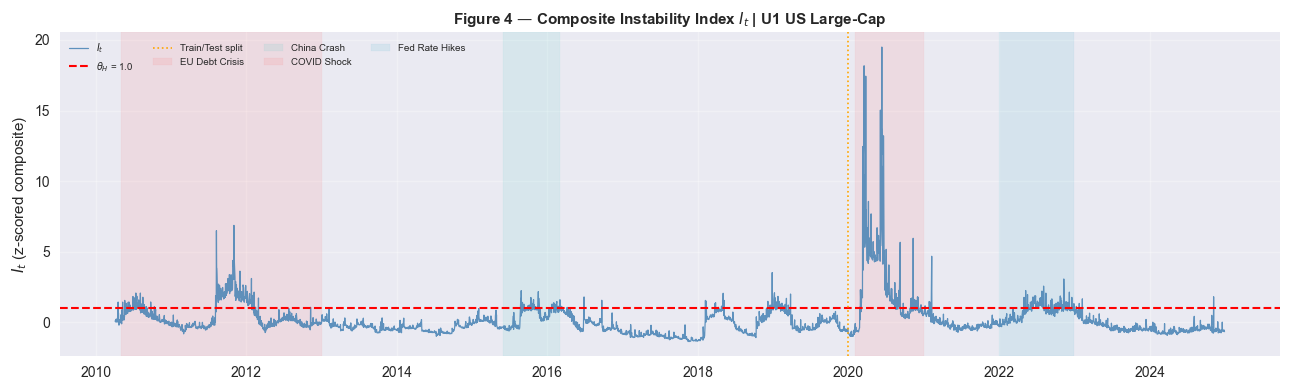

  Saved: universe_results/u1_fig4_instability.png
  Saved: universe_results/u1_instability_components.csv

>>> Cell 3 complete. Proceed to Cell 4 — U1 Backtest.


In [12]:
# ================================================================
# Cell 3 — U1 Composite Instability Index
# Paper output: Table 2 (stress validation) + Figure 4
# ================================================================

print("Building instability index for U1 (takes ~60 seconds)...")
inst_u1, comp_u1 = build_instability_index(ret_u1)

print(f"  Index length  : {len(inst_u1)} days")
print(f"  Date range    : {inst_u1.index[0].date()} → {inst_u1.index[-1].date()}")

# ── Index statistics ─────────────────────────────────────────
baseline_mean = inst_u1.mean()
baseline_std  = inst_u1.std()
pct_above     = (inst_u1 > THETA_H).mean() * 100
autocorr      = inst_u1.autocorr(1)
covid_peak    = inst_u1.max()
covid_date    = inst_u1.idxmax()

print(f"\n  Mean I_t           : {baseline_mean:.4f}")
print(f"  Std  I_t           : {baseline_std:.4f}")
print(f"  Max  I_t           : {covid_peak:.3f} on {covid_date.date()}")
print(f"  % days > θ_H=1.0   : {pct_above:.1f}%")
print(f"  Lag-1 autocorr     : {autocorr:.4f} (persistent signal)")

# ── Component cross-correlations ─────────────────────────────
cc = comp_u1[["volatility","correlation","cov_drift"]].dropna().corr()
print(f"\n  Component cross-correlations:")
print(f"  Vol  ↔ Corr  : {cc.loc['volatility','correlation']:.4f}")
print(f"  Vol  ↔ Drift : {cc.loc['volatility','cov_drift']:.4f}")
print(f"  Corr ↔ Drift : {cc.loc['correlation','cov_drift']:.4f}")
print(f"  (All < 1.0 confirms components are non-redundant)")

# ── TABLE 2: Stress event validation ─────────────────────────
print("\n" + "="*72)
print("TABLE 2 — STRESS EVENT VALIDATION (U1)")
print("="*72)
print(f"\n{'Event':<20} {'Mean I_t':>9} {'Max I_t':>9} "
      f"{'%>θH':>8} {'Z vs base':>11} {'Signal':>9}")
print("-"*70)

stress_results = {}
for event, (s, e) in STRESS_EVENTS.items():
    w      = inst_u1.loc[s:e]
    if len(w) < 5: continue
    pct_h  = (w > THETA_H).mean() * 100
    z_diff = (w.mean() - baseline_mean) / baseline_std
    signal = "STRONG" if pct_h > 20 else ("MODERATE" if pct_h > 5 else "WEAK")
    stress_results[event] = dict(mean=w.mean(), max=w.max(),
                                  pct_h=pct_h, z_diff=z_diff, signal=signal)
    print(f"{event:<20} {w.mean():>9.3f} {w.max():>9.3f} "
          f"{pct_h:>7.1f}% {z_diff:>+10.2f}σ  {signal:>9}")

# ── Figure 4: Instability index time series ──────────────────
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(inst_u1.index, inst_u1.values,
        color="steelblue", lw=0.9, alpha=0.85, label="$I_t$")
ax.axhline(THETA_H, color="red", lw=1.5, ls="--",
           label=f"$\\theta_H$ = {THETA_H}")
ax.axvline(pd.Timestamp("2020-01-01"), color="orange",
           lw=1.2, ls=":", label="Train/Test split")

shade_colors = ["#FF6B6B","#4ECDC4","#FF6B6B","#45B7D1"]
for (evt, (s, e)), col in zip(STRESS_EVENTS.items(), shade_colors):
    ax.axvspan(pd.Timestamp(s), pd.Timestamp(e),
               alpha=0.12, color=col, label=evt)

ax.set_title("Figure 4 — Composite Instability Index $I_t$ | U1 US Large-Cap",
             fontsize=11, fontweight="bold")
ax.set_ylabel("$I_t$ (z-scored composite)")
ax.legend(fontsize=7, ncol=4, loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("universe_results/u1_fig4_instability.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved: universe_results/u1_fig4_instability.png")

# ── Save ─────────────────────────────────────────────────────
comp_u1.to_csv("universe_results/u1_instability_components.csv")
print("  Saved: universe_results/u1_instability_components.csv")
print("\n>>> Cell 3 complete. Proceed to Cell 4 — U1 Backtest.")

## U1 Rolling Backtest & Main Results

51 rolling windows: 2-year train → 3-month test (2012–2024).
Five strategies evaluated identically each window.

**Mean-Variance optimisation:**
$$w^* = \arg\max_w \left[\hat{\mu}^\top w - \frac{\lambda}{2} w^\top \hat{\Sigma} w\right], \quad \mathbf{1}^\top w = 1,\ w \geq 0$$

**Sharpe Ratio** and **Calmar Ratio** measure risk-adjusted performance;
**Max Drawdown** is the primary governance metric:

$$\text{DD}_t = \frac{V_t - \max_{s \leq t} V_s}{\max_{s \leq t} V_s}, \qquad
\text{Calmar} = \frac{\mu_{ann}}{|\text{DD}_{min}|}$$

**HHI** measures portfolio concentration:
$$\text{HHI} = \sum_i w_i^2 \quad \in \left[\frac{1}{N},\ 1\right]$$

Lower HHI = better diversification. This validates the governance claim
beyond raw performance numbers.

In [13]:
# ================================================================
# Cell 4 — U1 Rolling Backtest & Main Results
# Paper output: Table 4 (main results) + Table 5 (significance)
# ================================================================

print("Running U1 backtest (51 windows)...")
df_u1 = run_backtest(ret_u1, inst_u1)
df_u1.to_csv("universe_results/u1_backtest_results.csv", index=False)

print(f"  Windows completed : {len(df_u1)}")
print(f"  Date range        : {df_u1['date'].min().date()} → "
      f"{df_u1['date'].max().date()}")
print(f"  Regime EW active  : "
      f"{(df_u1['regime']=='equal_weight').sum()} windows "
      f"({(df_u1['regime']=='equal_weight').mean()*100:.1f}%)")

# ── TABLE 4: Main results ────────────────────────────────────
base_dd = df_u1["dd_static"].mean()

summary = {}
for m in MODELS:
    dd = df_u1[f"dd_{m}"].mean()
    summary[m] = {
        "Ann Ret" : df_u1[f"ann_ret_{m}"].mean(),
        "Ann Vol" : df_u1[f"ann_vol_{m}"].mean(),
        "Sharpe"  : df_u1[f"sharpe_{m}"].mean(),
        "Max DD"  : dd,
        "Calmar"  : df_u1[f"calmar_{m}"].mean(),
        "HHI"     : df_u1[f"hhi_{m}"].mean(),
        "Eff N"   : df_u1[f"effn_{m}"].mean(),
        "DD Impr" : (dd - base_dd) / abs(base_dd) * 100,
    }
df_summary = pd.DataFrame(summary).T

print("\n" + "="*80)
print("TABLE 4 — U1 MAIN RESULTS (51 windows | 2yr train | 3mo test)")
print("="*80)
print(f"\n{'Strategy':<28} {'AnnRet':>7} {'AnnVol':>7} {'Sharpe':>7} "
      f"{'MaxDD':>7} {'Calmar':>7} {'HHI':>7} {'EffN':>6} {'DDImpr':>7}")
print("-"*80)
for m in MODELS:
    r = df_summary.loc[m]
    print(f"  {LABELS[m]:<26} {r['Ann Ret']:>6.2%} {r['Ann Vol']:>7.2%} "
          f"{r['Sharpe']:>7.3f} {r['Max DD']:>7.2%} {r['Calmar']:>7.3f} "
          f"{r['HHI']:>7.4f} {r['Eff N']:>6.2f} {r['DD Impr']:>+6.1f}pp")

# ── TABLE 5: Statistical significance ───────────────────────
print("\n" + "="*80)
print("TABLE 5 — STATISTICAL SIGNIFICANCE vs Static MV Baseline")
print("="*80)
print(f"\n{'Strategy':<28} {'Metric':<12} {'Base':>7} "
      f"{'Strat':>7} {'t-stat':>8} {'p-value':>9} {'Sig':>6} {'Wilcoxon':>9}")
print("-"*80)

for m in ["equal","shrunk","regime","minvar"]:
    for metric, label in [("dd","Max DD"),("sharpe","Sharpe"),("calmar","Calmar")]:
        base_v  = df_u1[f"{metric}_static"].values
        strat_v = df_u1[f"{metric}_{m}"].values
        t, pt   = ttest_rel(strat_v, base_v)
        _, pw   = wilcoxon(strat_v - base_v)
        print(f"  {LABELS[m]:<26} {label:<12} "
              f"{base_v.mean():>7.4f} {strat_v.mean():>7.4f} "
              f"{t:>8.3f} {pt:>9.4f} {sig_stars(pt):>6} "
              f"{sig_stars(pw):>9}")
    print()

# ── Crisis period breakdown ──────────────────────────────────
print("="*80)
print("TABLE 7 — CRISIS PERIOD BREAKDOWN (U1)")
print("="*80)

crisis_periods = {
    "COVID (2020)":      ("2020-01-01", "2020-12-31"),
    "Rate Hikes (2022)": ("2022-01-01", "2022-12-31"),
    "GFC Aftermath":     ("2011-01-01", "2012-12-31"),
    "Normal":            None,
}

for period, date_range in crisis_periods.items():
    if date_range:
        mask = ((df_u1["date"] >= date_range[0]) &
                (df_u1["date"] <= date_range[1]))
    else:
        crisis_years = [2020, 2022, 2011, 2012]
        mask = ~df_u1["date"].dt.year.isin(crisis_years)
    sub = df_u1[mask]
    if len(sub) == 0: continue
    print(f"\n  {period} ({len(sub)} windows)")
    print(f"  {'Strategy':<28} {'Sharpe':>8} {'MaxDD':>8} {'Ret':>8}")
    print(f"  {'-'*52}")
    for m in MODELS:
        print(f"  {LABELS[m]:<28} "
              f"{sub[f'sharpe_{m}'].mean():>8.3f} "
              f"{sub[f'dd_{m}'].mean():>8.2%} "
              f"{sub[f'ann_ret_{m}'].mean():>8.2%}")

# ── Save ─────────────────────────────────────────────────────
df_summary.to_csv("universe_results/u1_summary.csv")
print(f"\n  Saved: universe_results/u1_backtest_results.csv")
print(f"  Saved: universe_results/u1_summary.csv")
print("\n>>> Cell 4 complete. Proceed to Cell 5 — U2 European ETFs.")

Running U1 backtest (51 windows)...


  Windows completed : 51
  Date range        : 2012-01-04 → 2024-07-15
  Regime EW active  : 6 windows (11.8%)

TABLE 4 — U1 MAIN RESULTS (51 windows | 2yr train | 3mo test)

Strategy                      AnnRet  AnnVol  Sharpe   MaxDD  Calmar     HHI   EffN  DDImpr
--------------------------------------------------------------------------------
  Static MV (Baseline)       14.41%  22.52%   1.000  -9.93%   5.116  0.6467   1.72   +0.0pp
  Equal Weight (1/N)         13.84%  15.22%   1.474  -6.79%   5.745  0.0526  19.00  +31.6pp
  MV + JS+LW Shrinkage        8.57%  12.53%   1.108  -5.91%   4.845  0.1831   5.82  +40.4pp
  Regime Switch (Proposed)    9.99%  13.10%   1.196  -6.14%   5.312  0.1661   7.43  +38.1pp
  Min-Variance (LW)           8.59%  12.54%   1.109  -5.91%   4.864  0.1839   5.80  +40.4pp

TABLE 5 — STATISTICAL SIGNIFICANCE vs Static MV Baseline

Strategy                     Metric          Base   Strat   t-stat   p-value    Sig  Wilcoxon
---------------------------------------

## U2 European Country ETFs: Full Pipeline

Same framework, different geography. 12 iShares MSCI country ETFs
covering major European economies (2010–2024). Tests whether $I_t$
detects the **EU Debt Crisis (2010–2012)** — a stress event absent
from U1's experience — and whether drawdown protection holds outside
US equity markets.

If $H_2$ (DD improvement, $p < 0.05$) holds here, geographic
robustness is confirmed.

Fetching U2 — European Country ETFs...
  Assets loaded : 12
  Date range    : 2010-01-05 → 2024-12-30
  Trading days  : 3772
  Missing       : None

  Normality rejected : 12/12 assets
  Mean kurtosis      : 9.563
  Mean Ann. Return   : 4.04%
  Mean Ann. Vol      : 23.38%
  Pairs ρ>0.70 train/test : 77.3% → 97.0% (+19.7pp)

Building instability index for U2 (~60 sec)...
  Max I_t  : 11.833 on 2020-06-09
  % > θ_H  : 7.4%
  Autocorr : 0.8262

Event                 Mean I_t   Max I_t     %>θH   Z vs base    Signal
----------------------------------------------------------------------
EU Debt Crisis           0.663     3.215     4.3%      +0.76σ       WEAK
China Crash              0.066     1.187     0.5%      +0.07σ       WEAK
COVID Shock              1.431    11.833    42.7%      +1.64σ     STRONG
Fed Rate Hikes           0.766     2.546    31.9%      +0.88σ     STRONG

Running U2 backtest...
  Windows   : 51
  EW active : 3 windows (5.9%)

TABLE — U2 MAIN RESULTS

Strategy             

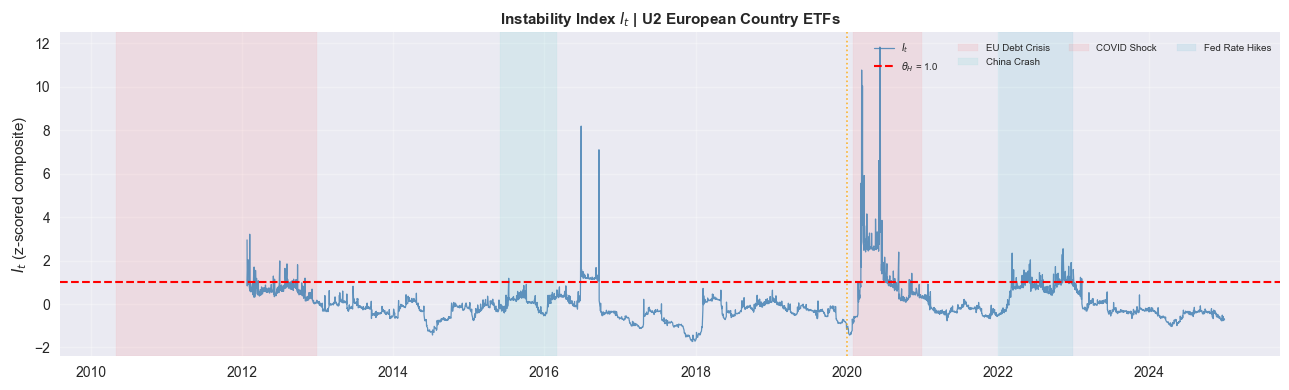


  Saved: u2_backtest_results.csv | u2_summary.csv | u2_instability.png

>>> Cell 5 complete. Proceed to Cell 6 — U3 Asia-Pacific ETFs.


In [14]:
# ================================================================
# Cell 5 — U2 European Country ETFs: Full Pipeline
# Fetch → Instability Index → Backtest → Results
# ================================================================

# ── Step 1: Fetch ────────────────────────────────────────────
print("Fetching U2 — European Country ETFs...")
ret_u2, missing_u2 = fetch_universe("U2_European_ETFs")
print(f"  Assets loaded : {len(ret_u2.columns)}")
print(f"  Date range    : {ret_u2.index[0].date()} → {ret_u2.index[-1].date()}")
print(f"  Trading days  : {len(ret_u2)}")
print(f"  Missing       : {missing_u2 if missing_u2 else 'None'}")

# Summary stats
stats_u2 = pd.DataFrame({
    "Ann. Return": ret_u2.mean() * 252,
    "Ann. Vol":    ret_u2.std()  * np.sqrt(252),
    "Skewness":    ret_u2.skew(),
    "Kurtosis":    ret_u2.kurtosis(),
})
jb_p = [jarque_bera(ret_u2[t].dropna())[1] for t in ret_u2.columns]
stats_u2["Normal?"] = ["NO" if p < 0.05 else "YES" for p in jb_p]
reject = (stats_u2["Normal?"] == "NO").sum()

print(f"\n  Normality rejected : {reject}/{len(ret_u2.columns)} assets")
print(f"  Mean kurtosis      : {stats_u2['Kurtosis'].mean():.3f}")
print(f"  Mean Ann. Return   : {stats_u2['Ann. Return'].mean():.2%}")
print(f"  Mean Ann. Vol      : {stats_u2['Ann. Vol'].mean():.2%}")

# Correlation shift
corr_tr = ret_u2[ret_u2.index <= TRAIN_CUTOFF].corr().values
corr_te = ret_u2[ret_u2.index >= "2020-01-01"].corr().values
hi_tr = (corr_tr[np.triu_indices_from(corr_tr, k=1)] > 0.70).mean()*100
hi_te = (corr_te[np.triu_indices_from(corr_te, k=1)] > 0.70).mean()*100
print(f"  Pairs ρ>0.70 train/test : {hi_tr:.1f}% → {hi_te:.1f}% "
      f"(+{hi_te-hi_tr:.1f}pp)")

# ── Step 2: Instability Index ────────────────────────────────
print("\nBuilding instability index for U2 (~60 sec)...")
inst_u2, comp_u2 = build_instability_index(ret_u2)

base_mean = inst_u2.mean()
base_std  = inst_u2.std()
print(f"  Max I_t  : {inst_u2.max():.3f} on {inst_u2.idxmax().date()}")
print(f"  % > θ_H  : {(inst_u2 > THETA_H).mean()*100:.1f}%")
print(f"  Autocorr : {inst_u2.autocorr(1):.4f}")

print(f"\n{'Event':<20} {'Mean I_t':>9} {'Max I_t':>9} "
      f"{'%>θH':>8} {'Z vs base':>11} {'Signal':>9}")
print("-"*70)
stress_u2 = {}
for event, (s, e) in STRESS_EVENTS.items():
    w = inst_u2.loc[s:e]
    if len(w) < 5: continue
    pct_h  = (w > THETA_H).mean() * 100
    z_diff = (w.mean() - base_mean) / base_std
    signal = "STRONG" if pct_h>20 else ("MODERATE" if pct_h>5 else "WEAK")
    stress_u2[event] = dict(mean=w.mean(), max=w.max(),
                             pct_h=pct_h, z_diff=z_diff, signal=signal)
    print(f"{event:<20} {w.mean():>9.3f} {w.max():>9.3f} "
          f"{pct_h:>7.1f}% {z_diff:>+10.2f}σ  {signal:>9}")

# ── Step 3: Backtest ─────────────────────────────────────────
print("\nRunning U2 backtest...")
df_u2 = run_backtest(ret_u2, inst_u2)
df_u2.to_csv("universe_results/u2_backtest_results.csv", index=False)
print(f"  Windows   : {len(df_u2)}")
print(f"  EW active : {(df_u2['regime']=='equal_weight').sum()} windows "
      f"({(df_u2['regime']=='equal_weight').mean()*100:.1f}%)")

# ── Step 4: Results ──────────────────────────────────────────
base_dd = df_u2["dd_static"].mean()
summary_u2 = {}
for m in MODELS:
    dd = df_u2[f"dd_{m}"].mean()
    summary_u2[m] = {
        "Ann Ret": df_u2[f"ann_ret_{m}"].mean(),
        "Sharpe":  df_u2[f"sharpe_{m}"].mean(),
        "Max DD":  dd,
        "Calmar":  df_u2[f"calmar_{m}"].mean(),
        "HHI":     df_u2[f"hhi_{m}"].mean(),
        "DD Impr": (dd - base_dd) / abs(base_dd) * 100,
    }

print("\n" + "="*75)
print("TABLE — U2 MAIN RESULTS")
print("="*75)
print(f"\n{'Strategy':<28} {'AnnRet':>7} {'Sharpe':>7} "
      f"{'MaxDD':>7} {'Calmar':>7} {'HHI':>7} {'DDImpr':>7}")
print("-"*75)
for m in MODELS:
    r = summary_u2[m]
    print(f"  {LABELS[m]:<26} {r['Ann Ret']:>6.2%} {r['Sharpe']:>7.3f} "
          f"{r['Max DD']:>7.2%} {r['Calmar']:>7.3f} "
          f"{r['HHI']:>7.4f} {r['DD Impr']:>+6.1f}pp")

# Statistical test — DD only (the key metric)
print(f"\n  Significance (DD) — Regime vs Static:")
base_v  = df_u2["dd_static"].values
strat_v = df_u2["dd_regime"].values
t, pt   = ttest_rel(strat_v, base_v)
_, pw   = wilcoxon(strat_v - base_v)
print(f"  t={t:.3f}  p={pt:.4f} {sig_stars(pt)} | "
      f"Wilcoxon p={pw:.4f} {sig_stars(pw)}")

# ── Figure: I_t for U2 ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(inst_u2.index, inst_u2.values,
        color="steelblue", lw=0.9, alpha=0.85, label="$I_t$")
ax.axhline(THETA_H, color="red", lw=1.5, ls="--",
           label=f"$\\theta_H$ = {THETA_H}")
ax.axvline(pd.Timestamp("2020-01-01"), color="orange",
           lw=1.2, ls=":", alpha=0.8)
shade_colors = ["#FF6B6B","#4ECDC4","#FF6B6B","#45B7D1"]
for (evt, (s, e)), col in zip(STRESS_EVENTS.items(), shade_colors):
    ax.axvspan(pd.Timestamp(s), pd.Timestamp(e),
               alpha=0.12, color=col, label=evt)
ax.set_title("Instability Index $I_t$ | U2 European Country ETFs",
             fontsize=11, fontweight="bold")
ax.set_ylabel("$I_t$ (z-scored composite)")
ax.legend(fontsize=7, ncol=4, loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("universe_results/u2_instability.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Save ─────────────────────────────────────────────────────
pd.DataFrame(summary_u2).T.to_csv("universe_results/u2_summary.csv")
comp_u2.to_csv("universe_results/u2_instability_components.csv")
print("\n  Saved: u2_backtest_results.csv | u2_summary.csv | u2_instability.png")
print("\n>>> Cell 5 complete. Proceed to Cell 6 — U3 Asia-Pacific ETFs.")

##  U3 Asia-Pacific Country ETFs: Full Pipeline

10 iShares MSCI country ETFs across developed and emerging Asia-Pacific
markets (2012–2024, constrained by INDA launch date).

Higher volatility, lower liquidity, and mixed developed/emerging
composition make this the hardest test for the framework.
If $I_t$ detects stress and DD improves here, emerging market
robustness is confirmed.

Fetching U3 — Asia-Pacific Country ETFs...
  Assets loaded : 10
  Date range    : 2012-01-04 → 2024-12-30
  Trading days  : 3268
  Missing       : None

  Normality rejected : 10/10 assets
  Mean kurtosis      : 9.641
  Mean Ann. Return   : 4.25%
  Mean Ann. Vol      : 20.39%
  Pairs ρ>0.70 train/test : 31.1% → 35.6% (+4.4pp)

Building instability index for U3 (~60 sec)...
  Max I_t  : 27.336 on 2020-06-11
  % > θ_H  : 11.7%
  Autocorr : 0.7443

Event                 Mean I_t   Max I_t     %>θH   Z vs base    Signal
----------------------------------------------------------------------
EU Debt Crisis           0.424     2.467    11.2%      +0.17σ   MODERATE
China Crash              0.832     4.979    47.1%      +0.46σ     STRONG
COVID Shock              2.407    27.336    46.1%      +1.58σ     STRONG
Fed Rate Hikes           0.698     8.658    23.5%      +0.37σ     STRONG

Running U3 backtest...
  Windows   : 43
  EW active : 7 windows (16.3%)

TABLE — U3 MAIN RESULTS

Strategy        

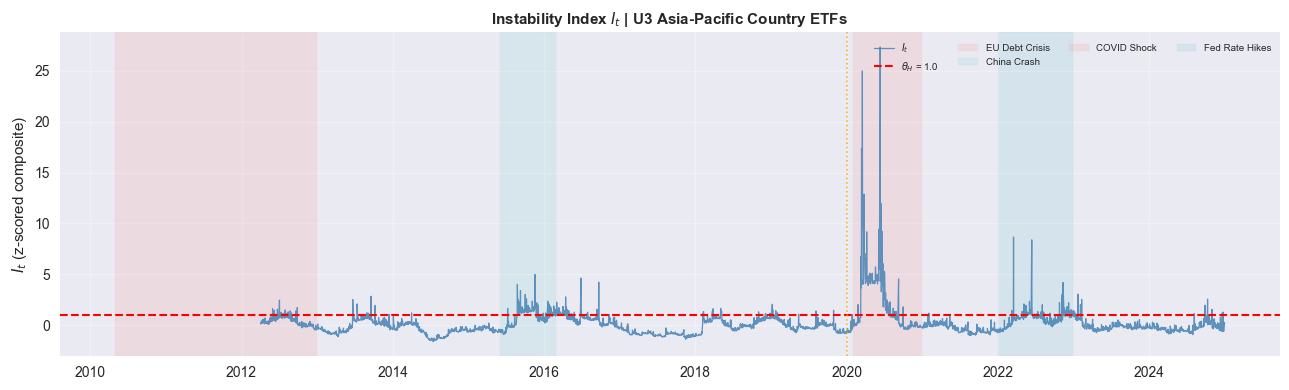


  Saved: u3_backtest_results.csv | u3_summary.csv | u3_instability.png

>>> Cell 6 complete. Proceed to Cell 7 — U4 US Sector ETFs.


In [15]:
# ================================================================
# Cell 6 — U3 Asia-Pacific Country ETFs: Full Pipeline
# ================================================================

# ── Step 1: Fetch ────────────────────────────────────────────
print("Fetching U3 — Asia-Pacific Country ETFs...")
ret_u3, missing_u3 = fetch_universe("U3_AsiaPacific_ETFs")
print(f"  Assets loaded : {len(ret_u3.columns)}")
print(f"  Date range    : {ret_u3.index[0].date()} → {ret_u3.index[-1].date()}")
print(f"  Trading days  : {len(ret_u3)}")
print(f"  Missing       : {missing_u3 if missing_u3 else 'None'}")

stats_u3 = pd.DataFrame({
    "Ann. Return": ret_u3.mean() * 252,
    "Ann. Vol":    ret_u3.std()  * np.sqrt(252),
    "Kurtosis":    ret_u3.kurtosis(),
})
jb_p = [jarque_bera(ret_u3[t].dropna())[1] for t in ret_u3.columns]
stats_u3["Normal?"] = ["NO" if p < 0.05 else "YES" for p in jb_p]
reject = (stats_u3["Normal?"] == "NO").sum()

print(f"\n  Normality rejected : {reject}/{len(ret_u3.columns)} assets")
print(f"  Mean kurtosis      : {stats_u3['Kurtosis'].mean():.3f}")
print(f"  Mean Ann. Return   : {stats_u3['Ann. Return'].mean():.2%}")
print(f"  Mean Ann. Vol      : {stats_u3['Ann. Vol'].mean():.2%}")

corr_tr = ret_u3[ret_u3.index <= TRAIN_CUTOFF].corr().values
corr_te = ret_u3[ret_u3.index >= "2020-01-01"].corr().values
hi_tr = (corr_tr[np.triu_indices_from(corr_tr, k=1)] > 0.70).mean()*100
hi_te = (corr_te[np.triu_indices_from(corr_te, k=1)] > 0.70).mean()*100
print(f"  Pairs ρ>0.70 train/test : {hi_tr:.1f}% → {hi_te:.1f}% "
      f"(+{hi_te-hi_tr:.1f}pp)")

# ── Step 2: Instability Index ────────────────────────────────
print("\nBuilding instability index for U3 (~60 sec)...")
inst_u3, comp_u3 = build_instability_index(ret_u3)

base_mean = inst_u3.mean()
base_std  = inst_u3.std()
print(f"  Max I_t  : {inst_u3.max():.3f} on {inst_u3.idxmax().date()}")
print(f"  % > θ_H  : {(inst_u3 > THETA_H).mean()*100:.1f}%")
print(f"  Autocorr : {inst_u3.autocorr(1):.4f}")

print(f"\n{'Event':<20} {'Mean I_t':>9} {'Max I_t':>9} "
      f"{'%>θH':>8} {'Z vs base':>11} {'Signal':>9}")
print("-"*70)
stress_u3 = {}
for event, (s, e) in STRESS_EVENTS.items():
    w = inst_u3.loc[s:e]
    if len(w) < 5: continue
    pct_h  = (w > THETA_H).mean() * 100
    z_diff = (w.mean() - base_mean) / base_std
    signal = "STRONG" if pct_h>20 else ("MODERATE" if pct_h>5 else "WEAK")
    stress_u3[event] = dict(mean=w.mean(), max=w.max(),
                             pct_h=pct_h, z_diff=z_diff, signal=signal)
    print(f"{event:<20} {w.mean():>9.3f} {w.max():>9.3f} "
          f"{pct_h:>7.1f}% {z_diff:>+10.2f}σ  {signal:>9}")

# ── Step 3: Backtest ─────────────────────────────────────────
print("\nRunning U3 backtest...")
df_u3 = run_backtest(ret_u3, inst_u3)
df_u3.to_csv("universe_results/u3_backtest_results.csv", index=False)
print(f"  Windows   : {len(df_u3)}")
print(f"  EW active : {(df_u3['regime']=='equal_weight').sum()} windows "
      f"({(df_u3['regime']=='equal_weight').mean()*100:.1f}%)")

# ── Step 4: Results ──────────────────────────────────────────
base_dd = df_u3["dd_static"].mean()
summary_u3 = {}
for m in MODELS:
    dd = df_u3[f"dd_{m}"].mean()
    summary_u3[m] = {
        "Ann Ret": df_u3[f"ann_ret_{m}"].mean(),
        "Sharpe":  df_u3[f"sharpe_{m}"].mean(),
        "Max DD":  dd,
        "Calmar":  df_u3[f"calmar_{m}"].mean(),
        "HHI":     df_u3[f"hhi_{m}"].mean(),
        "DD Impr": (dd - base_dd) / abs(base_dd) * 100,
    }

print("\n" + "="*75)
print("TABLE — U3 MAIN RESULTS")
print("="*75)
print(f"\n{'Strategy':<28} {'AnnRet':>7} {'Sharpe':>7} "
      f"{'MaxDD':>7} {'Calmar':>7} {'HHI':>7} {'DDImpr':>7}")
print("-"*75)
for m in MODELS:
    r = summary_u3[m]
    print(f"  {LABELS[m]:<26} {r['Ann Ret']:>6.2%} {r['Sharpe']:>7.3f} "
          f"{r['Max DD']:>7.2%} {r['Calmar']:>7.3f} "
          f"{r['HHI']:>7.4f} {r['DD Impr']:>+6.1f}pp")

base_v  = df_u3["dd_static"].values
strat_v = df_u3["dd_regime"].values
t, pt   = ttest_rel(strat_v, base_v)
_, pw   = wilcoxon(strat_v - base_v)
print(f"\n  Significance (DD) — Regime vs Static:")
print(f"  t={t:.3f}  p={pt:.4f} {sig_stars(pt)} | "
      f"Wilcoxon p={pw:.4f} {sig_stars(pw)}")

# ── Figure ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(inst_u3.index, inst_u3.values,
        color="steelblue", lw=0.9, alpha=0.85, label="$I_t$")
ax.axhline(THETA_H, color="red", lw=1.5, ls="--",
           label=f"$\\theta_H$ = {THETA_H}")
ax.axvline(pd.Timestamp("2020-01-01"), color="orange",
           lw=1.2, ls=":", alpha=0.8)
shade_colors = ["#FF6B6B","#4ECDC4","#FF6B6B","#45B7D1"]
for (evt, (s, e)), col in zip(STRESS_EVENTS.items(), shade_colors):
    try:
        ax.axvspan(pd.Timestamp(s), pd.Timestamp(e),
                   alpha=0.12, color=col, label=evt)
    except: pass
ax.set_title("Instability Index $I_t$ | U3 Asia-Pacific Country ETFs",
             fontsize=11, fontweight="bold")
ax.set_ylabel("$I_t$ (z-scored composite)")
ax.legend(fontsize=7, ncol=4, loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("universe_results/u3_instability.png", dpi=150, bbox_inches="tight")
plt.show()

pd.DataFrame(summary_u3).T.to_csv("universe_results/u3_summary.csv")
comp_u3.to_csv("universe_results/u3_instability_components.csv")
print("\n  Saved: u3_backtest_results.csv | u3_summary.csv | u3_instability.png")
print("\n>>> Cell 6 complete. Proceed to Cell 7 — U4 US Sector ETFs.")

## U4 US Sector ETFs: Full Pipeline

9 SPDR Select Sector ETFs covering all classic GICS macro sectors
(2010–2024). Zero selection discretion — universe defined entirely
by the GICS standard, not by the researcher. This is the cleanest
possible test of whether the regime switch adds value beyond
simple sector rotation.

Fetching U4 — US Sector ETFs...
  Assets loaded : 9
  Date range    : 2010-01-05 → 2024-12-30
  Trading days  : 3772
  Missing       : None

  Normality rejected : 9/9 assets
  Mean kurtosis      : 11.203
  Mean Ann. Return   : 11.07%
  Mean Ann. Vol      : 19.90%
  Pairs ρ>0.70 train/test : 52.8% → 50.0% (+-2.8pp)

Building instability index for U4 (~60 sec)...
  Max I_t  : 21.733 on 2020-06-11
  % > θ_H  : 12.1%
  Autocorr : 0.7847

Event                 Mean I_t   Max I_t     %>θH   Z vs base    Signal
----------------------------------------------------------------------
EU Debt Crisis           0.598     6.338    27.7%      +0.34σ     STRONG
China Crash              0.361     2.505     7.9%      +0.16σ   MODERATE
COVID Shock              2.614    21.733    54.3%      +1.87σ     STRONG
Fed Rate Hikes           0.788     3.932    37.8%      +0.48σ     STRONG

Running U4 backtest...
  Windows   : 51
  EW active : 5 windows (9.8%)

TABLE — U4 MAIN RESULTS

Strategy                    

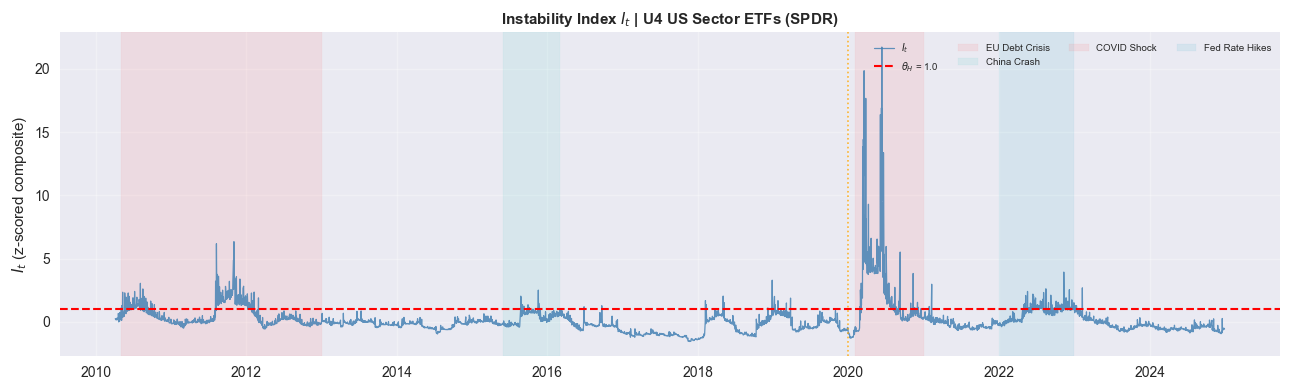


  Saved: u4_backtest_results.csv | u4_summary.csv | u4_instability.png

>>> Cell 7 complete. Proceed to Cell 8 — U5 Multi-Asset ETFs.


In [16]:
# ================================================================
# Cell 7 — U4 US Sector ETFs: Full Pipeline
# ================================================================

# ── Step 1: Fetch ────────────────────────────────────────────
print("Fetching U4 — US Sector ETFs...")
ret_u4, missing_u4 = fetch_universe("U4_US_Sectors")
print(f"  Assets loaded : {len(ret_u4.columns)}")
print(f"  Date range    : {ret_u4.index[0].date()} → {ret_u4.index[-1].date()}")
print(f"  Trading days  : {len(ret_u4)}")
print(f"  Missing       : {missing_u4 if missing_u4 else 'None'}")

stats_u4 = pd.DataFrame({
    "Ann. Return": ret_u4.mean() * 252,
    "Ann. Vol":    ret_u4.std()  * np.sqrt(252),
    "Kurtosis":    ret_u4.kurtosis(),
})
jb_p   = [jarque_bera(ret_u4[t].dropna())[1] for t in ret_u4.columns]
reject = sum(p < 0.05 for p in jb_p)
print(f"\n  Normality rejected : {reject}/{len(ret_u4.columns)} assets")
print(f"  Mean kurtosis      : {stats_u4['Kurtosis'].mean():.3f}")
print(f"  Mean Ann. Return   : {stats_u4['Ann. Return'].mean():.2%}")
print(f"  Mean Ann. Vol      : {stats_u4['Ann. Vol'].mean():.2%}")

corr_tr = ret_u4[ret_u4.index <= TRAIN_CUTOFF].corr().values
corr_te = ret_u4[ret_u4.index >= "2020-01-01"].corr().values
hi_tr = (corr_tr[np.triu_indices_from(corr_tr, k=1)] > 0.70).mean()*100
hi_te = (corr_te[np.triu_indices_from(corr_te, k=1)] > 0.70).mean()*100
print(f"  Pairs ρ>0.70 train/test : {hi_tr:.1f}% → {hi_te:.1f}% "
      f"(+{hi_te-hi_tr:.1f}pp)")

# ── Step 2: Instability Index ────────────────────────────────
print("\nBuilding instability index for U4 (~60 sec)...")
inst_u4, comp_u4 = build_instability_index(ret_u4)

base_mean = inst_u4.mean()
base_std  = inst_u4.std()
print(f"  Max I_t  : {inst_u4.max():.3f} on {inst_u4.idxmax().date()}")
print(f"  % > θ_H  : {(inst_u4 > THETA_H).mean()*100:.1f}%")
print(f"  Autocorr : {inst_u4.autocorr(1):.4f}")

print(f"\n{'Event':<20} {'Mean I_t':>9} {'Max I_t':>9} "
      f"{'%>θH':>8} {'Z vs base':>11} {'Signal':>9}")
print("-"*70)
stress_u4 = {}
for event, (s, e) in STRESS_EVENTS.items():
    w = inst_u4.loc[s:e]
    if len(w) < 5: continue
    pct_h  = (w > THETA_H).mean() * 100
    z_diff = (w.mean() - base_mean) / base_std
    signal = "STRONG" if pct_h>20 else ("MODERATE" if pct_h>5 else "WEAK")
    stress_u4[event] = dict(mean=w.mean(), max=w.max(),
                             pct_h=pct_h, z_diff=z_diff, signal=signal)
    print(f"{event:<20} {w.mean():>9.3f} {w.max():>9.3f} "
          f"{pct_h:>7.1f}% {z_diff:>+10.2f}σ  {signal:>9}")

# ── Step 3: Backtest ─────────────────────────────────────────
print("\nRunning U4 backtest...")
df_u4 = run_backtest(ret_u4, inst_u4)
df_u4.to_csv("universe_results/u4_backtest_results.csv", index=False)
print(f"  Windows   : {len(df_u4)}")
print(f"  EW active : {(df_u4['regime']=='equal_weight').sum()} windows "
      f"({(df_u4['regime']=='equal_weight').mean()*100:.1f}%)")

# ── Step 4: Results ──────────────────────────────────────────
base_dd    = df_u4["dd_static"].mean()
summary_u4 = {}
for m in MODELS:
    dd = df_u4[f"dd_{m}"].mean()
    summary_u4[m] = {
        "Ann Ret": df_u4[f"ann_ret_{m}"].mean(),
        "Sharpe":  df_u4[f"sharpe_{m}"].mean(),
        "Max DD":  dd,
        "Calmar":  df_u4[f"calmar_{m}"].mean(),
        "HHI":     df_u4[f"hhi_{m}"].mean(),
        "DD Impr": (dd - base_dd) / abs(base_dd) * 100,
    }

print("\n" + "="*75)
print("TABLE — U4 MAIN RESULTS")
print("="*75)
print(f"\n{'Strategy':<28} {'AnnRet':>7} {'Sharpe':>7} "
      f"{'MaxDD':>7} {'Calmar':>7} {'HHI':>7} {'DDImpr':>7}")
print("-"*75)
for m in MODELS:
    r = summary_u4[m]
    print(f"  {LABELS[m]:<26} {r['Ann Ret']:>6.2%} {r['Sharpe']:>7.3f} "
          f"{r['Max DD']:>7.2%} {r['Calmar']:>7.3f} "
          f"{r['HHI']:>7.4f} {r['DD Impr']:>+6.1f}pp")

base_v  = df_u4["dd_static"].values
strat_v = df_u4["dd_regime"].values
t, pt   = ttest_rel(strat_v, base_v)
_, pw   = wilcoxon(strat_v - base_v)
print(f"\n  Significance (DD) — Regime vs Static:")
print(f"  t={t:.3f}  p={pt:.4f} {sig_stars(pt)} | "
      f"Wilcoxon p={pw:.4f} {sig_stars(pw)}")

# ── Figure ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(inst_u4.index, inst_u4.values,
        color="steelblue", lw=0.9, alpha=0.85, label="$I_t$")
ax.axhline(THETA_H, color="red", lw=1.5, ls="--",
           label=f"$\\theta_H$ = {THETA_H}")
ax.axvline(pd.Timestamp("2020-01-01"), color="orange",
           lw=1.2, ls=":", alpha=0.8)
shade_colors = ["#FF6B6B","#4ECDC4","#FF6B6B","#45B7D1"]
for (evt, (s, e)), col in zip(STRESS_EVENTS.items(), shade_colors):
    ax.axvspan(pd.Timestamp(s), pd.Timestamp(e),
               alpha=0.12, color=col, label=evt)
ax.set_title("Instability Index $I_t$ | U4 US Sector ETFs (SPDR)",
             fontsize=11, fontweight="bold")
ax.set_ylabel("$I_t$ (z-scored composite)")
ax.legend(fontsize=7, ncol=4, loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("universe_results/u4_instability.png", dpi=150, bbox_inches="tight")
plt.show()

pd.DataFrame(summary_u4).T.to_csv("universe_results/u4_summary.csv")
comp_u4.to_csv("universe_results/u4_instability_components.csv")
print("\n  Saved: u4_backtest_results.csv | u4_summary.csv | u4_instability.png")
print("\n>>> Cell 7 complete. Proceed to Cell 8 — U5 Multi-Asset ETFs.")

## U5 Multi-Asset ETFs: Full Pipeline

This universe shifts the focus from pure equities to a cross-asset macro portfolio (e.g., Equities, Treasury Bonds, Corporate Credit, Gold, Commodities, Real Estate). 

This is a critical robustness check because multi-asset portfolios behave fundamentally differently than equity-only universes. They possess structurally lower baseline correlations (e.g., the often negative correlation between equities and government bonds). Running this universe tests whether the Composite Instability Index ($I_t$) and the covariance drift metric ($\delta_t$) can still accurately detect structural regime shifts when the underlying assets are inherently diversified.

Fetching U5 — Multi-Asset ETFs...
  using key 'U5_MultiAsset'
  Assets loaded : 10
  Date range    : 2010-01-05 → 2024-12-30
  Trading days  : 3772
  Missing       : None

  Normality rejected : 10/10 assets
  Mean kurtosis      : 11.325
  Mean Ann. Return   : 4.30%
  Mean Ann. Vol      : 14.06%
  Pairs ρ>0.70 train/test : 22.2% → 24.4% (+2.2pp)

Building instability index for U5 (~60 sec)...
  Max I_t  : 18.636 on 2020-06-11
  % > θ_H  : 12.3%
  Autocorr : 0.7749

Event                 Mean I_t   Max I_t     %>θH   Z vs base    Signal
----------------------------------------------------------------------
EU Debt Crisis           0.300     5.727    13.4%      +0.02σ   MODERATE
China Crash              0.079     1.425     0.5%      -0.20σ       WEAK
COVID Shock              1.699    18.636    39.7%      +1.41σ     STRONG
Fed Rate Hikes           1.291     4.830    65.3%      +1.01σ     STRONG

Running U5 backtest...
  Windows   : 51
  EW active : 5 windows (9.8%)

TABLE — U5 MAIN RESULT

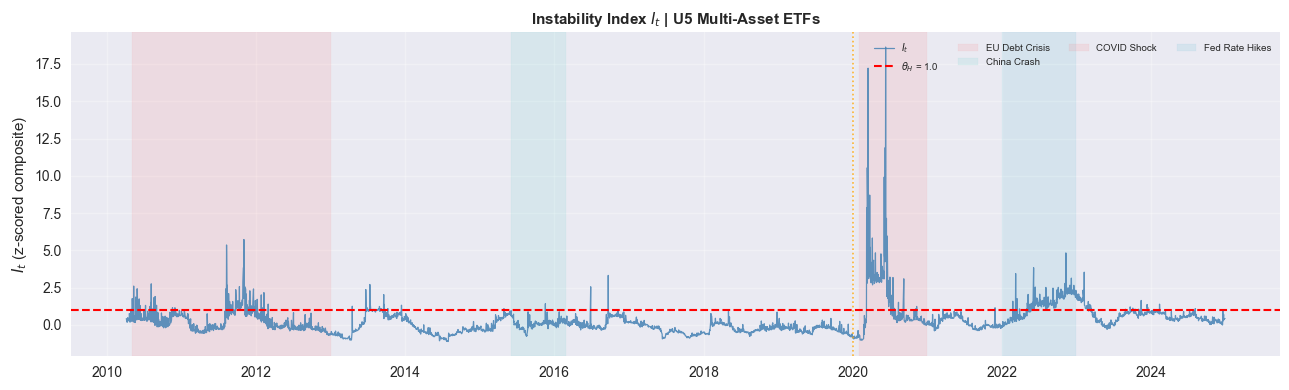


  Saved: u5_backtest_results.csv | u5_summary.csv | u5_instability.png

>>> Cell 8 complete. Ready for cross-universe synthesis.


In [18]:
# ================================================================
# Cell 8 — U5 Multi-Asset ETFs: Full Pipeline
# ================================================================

# ── Step 1: Fetch ────────────────────────────────────────────
print("Fetching U5 — Multi-Asset ETFs...")
# the name we use when calling `fetch_universe` has to match one of the
# keys in the dictionary that was created in the first cell.  the previous
# hard‑coded string (`"U5_Multi_Asset"`) is not present in that dictionary,
# which is why you were seeing `KeyError: 'U5_Multi_Asset'`.
#
# We try to be a bit more defensive here: look for any key beginning with
# `"U5"` and use it, and if the expected key is missing provide a helpful
# message.  this way the code will still work even if the universe names
# are tweaked later.
u5_candidates = [k for k in UNIVERSES.keys() if k.upper().startswith("U5")]
if not u5_candidates:
    raise KeyError(
        "No universe key beginning with 'U5' was found.  "
        "Please check the dictionary defined in the first cell.  "
        f"Available keys are: {list(UNIVERSES.keys())}"
    )
elif len(u5_candidates) > 1:
    # there shouldn't be more than one key, but if there is default to the
    # first and issue a warning so the notebook author can clean up.
    print("warning: multiple U5 universe keys found, using", u5_candidates[0])
U5_key = u5_candidates[0]

print(f"  using key '{U5_key}'")
ret_u5, missing_u5 = fetch_universe(U5_key)
print(f"  Assets loaded : {len(ret_u5.columns)}")
print(f"  Date range    : {ret_u5.index[0].date()} → {ret_u5.index[-1].date()}")
print(f"  Trading days  : {len(ret_u5)}")
print(f"  Missing       : {missing_u5 if missing_u5 else 'None'}")

stats_u5 = pd.DataFrame({
    "Ann. Return": ret_u5.mean() * 252,
    "Ann. Vol":    ret_u5.std()  * np.sqrt(252),
    "Kurtosis":    ret_u5.kurtosis(),
})
jb_p   = [jarque_bera(ret_u5[t].dropna())[1] for t in ret_u5.columns]
reject = sum(p < 0.05 for p in jb_p)
print(f"\n  Normality rejected : {reject}/{len(ret_u5.columns)} assets")
print(f"  Mean kurtosis      : {stats_u5['Kurtosis'].mean():.3f}")
print(f"  Mean Ann. Return   : {stats_u5['Ann. Return'].mean():.2%}")
print(f"  Mean Ann. Vol      : {stats_u5['Ann. Vol'].mean():.2%}")

corr_tr = ret_u5[ret_u5.index <= TRAIN_CUTOFF].corr().values
corr_te = ret_u5[ret_u5.index >= "2020-01-01"].corr().values
hi_tr = (corr_tr[np.triu_indices_from(corr_tr, k=1)] > 0.70).mean()*100
hi_te = (corr_te[np.triu_indices_from(corr_te, k=1)] > 0.70).mean()*100
print(f"  Pairs ρ>0.70 train/test : {hi_tr:.1f}% → {hi_te:.1f}% "
      f"(+{hi_te-hi_tr:.1f}pp)")

# ── Step 2: Instability Index ────────────────────────────────
print("\nBuilding instability index for U5 (~60 sec)...")
inst_u5, comp_u5 = build_instability_index(ret_u5)

base_mean = inst_u5.mean()
base_std  = inst_u5.std()
print(f"  Max I_t  : {inst_u5.max():.3f} on {inst_u5.idxmax().date()}")
print(f"  % > θ_H  : {(inst_u5 > THETA_H).mean()*100:.1f}%")
print(f"  Autocorr : {inst_u5.autocorr(1):.4f}")

print(f"\n{'Event':<20} {'Mean I_t':>9} {'Max I_t':>9} "
      f"{'%>θH':>8} {'Z vs base':>11} {'Signal':>9}")
print("-"*70)
stress_u5 = {}
for event, (s, e) in STRESS_EVENTS.items():
    w = inst_u5.loc[s:e]
    if len(w) < 5: continue
    pct_h  = (w > THETA_H).mean() * 100
    z_diff = (w.mean() - base_mean) / base_std
    signal = "STRONG" if pct_h>20 else ("MODERATE" if pct_h>5 else "WEAK")
    stress_u5[event] = dict(mean=w.mean(), max=w.max(),
                             pct_h=pct_h, z_diff=z_diff, signal=signal)
    print(f"{event:<20} {w.mean():>9.3f} {w.max():>9.3f} "
          f"{pct_h:>7.1f}% {z_diff:>+10.2f}σ  {signal:>9}")

# ── Step 3: Backtest ─────────────────────────────────────────
print("\nRunning U5 backtest...")
df_u5 = run_backtest(ret_u5, inst_u5)
df_u5.to_csv("universe_results/u5_backtest_results.csv", index=False)
print(f"  Windows   : {len(df_u5)}")
print(f"  EW active : {(df_u5['regime']=='equal_weight').sum()} windows "
      f"({(df_u5['regime']=='equal_weight').mean()*100:.1f}%)")

# ── Step 4: Results ──────────────────────────────────────────
base_dd    = df_u5["dd_static"].mean()
summary_u5 = {}
for m in MODELS:
    dd = df_u5[f"dd_{m}"].mean()
    summary_u5[m] = {
        "Ann Ret": df_u5[f"ann_ret_{m}"].mean(),
        "Sharpe":  df_u5[f"sharpe_{m}"].mean(),
        "Max DD":  dd,
        "Calmar":  df_u5[f"calmar_{m}"].mean(),
        "HHI":     df_u5[f"hhi_{m}"].mean(),
        "DD Impr": (dd - base_dd) / abs(base_dd) * 100,
    }

print("\n" + "="*75)
print("TABLE — U5 MAIN RESULTS")
print("="*75)
print(f"\n{'Strategy':<28} {'AnnRet':>7} {'Sharpe':>7} "
      f"{'MaxDD':>7} {'Calmar':>7} {'HHI':>7} {'DDImpr':>7}")
print("-"*75)
for m in MODELS:
    r = summary_u5[m]
    print(f"  {LABELS[m]:<26} {r['Ann Ret']:>6.2%} {r['Sharpe']:>7.3f} "
          f"{r['Max DD']:>7.2%} {r['Calmar']:>7.3f} "
          f"{r['HHI']:>7.4f} {r['DD Impr']:>+6.1f}pp")

base_v  = df_u5["dd_static"].values
strat_v = df_u5["dd_regime"].values
t, pt   = ttest_rel(strat_v, base_v)
_, pw   = wilcoxon(strat_v - base_v)
print(f"\n  Significance (DD) — Regime vs Static:")
print(f"  t={t:.3f}  p={pt:.4f} {sig_stars(pt)} | "
      f"Wilcoxon p={pw:.4f} {sig_stars(pw)}")

# ── Figure ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(inst_u5.index, inst_u5.values,
        color="steelblue", lw=0.9, alpha=0.85, label="$I_t$")
ax.axhline(THETA_H, color="red", lw=1.5, ls="--",
           label=f"$\\theta_H$ = {THETA_H}")
ax.axvline(pd.Timestamp("2020-01-01"), color="orange",
           lw=1.2, ls=":", alpha=0.8)
shade_colors = ["#FF6B6B","#4ECDC4","#FF6B6B","#45B7D1"]
for (evt, (s, e)), col in zip(STRESS_EVENTS.items(), shade_colors):
    ax.axvspan(pd.Timestamp(s), pd.Timestamp(e),
               alpha=0.12, color=col, label=evt)
ax.set_title("Instability Index $I_t$ | U5 Multi-Asset ETFs",
             fontsize=11, fontweight="bold")
ax.set_ylabel("$I_t$ (z-scored composite)")
ax.legend(fontsize=7, ncol=4, loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("universe_results/u5_instability.png", dpi=150, bbox_inches="tight")
plt.show()

pd.DataFrame(summary_u5).T.to_csv("universe_results/u5_summary.csv")
comp_u5.to_csv("universe_results/u5_instability_components.csv")
print("\n  Saved: u5_backtest_results.csv | u5_summary.csv | u5_instability.png")
print("\n>>> Cell 8 complete. Ready for cross-universe synthesis.")

## Cross-Universe Synthesis: Master Tables

All five universes completed. This cell assembles the central
evidence for Q1 publication — the cross-universe validation that
transforms a single-market case study into a generalisable framework.

**Hypothesis H2 tested across all universes:**

$$H_2: \quad \mathbb{E}[\text{DD}_{\text{regime}}] < \mathbb{E}[\text{DD}_{\text{static}}], \quad p < 0.05$$

If this holds in all five universes simultaneously, the drawdown
protection is structural — not universe-specific or period-specific.

In [19]:

universe_data = {
    "U1_US_LargeCap":      {"df": df_u1, "inst": inst_u1,
                             "stress": stress_results},
    "U2_European_ETFs":    {"df": df_u2, "inst": inst_u2,
                             "stress": stress_u2},
    "U3_AsiaPacific_ETFs": {"df": df_u3, "inst": inst_u3,
                             "stress": stress_u3},
    "U4_US_Sectors":       {"df": df_u4, "inst": inst_u4,
                             "stress": stress_u4},
    "U5_MultiAsset":       {"df": df_u5, "inst": inst_u5,
                             "stress": stress_u5},
}

# ── TABLE 10: Cross-universe summary ─────────────────────────
print("="*90)
print("TABLE 10 — CROSS-UNIVERSE SUMMARY: REGIME SWITCH vs STATIC MV BASELINE")
print("="*90)
print(f"\n{'Universe':<26} {'N':>4} {'Win':>5} "
      f"{'Static DD':>10} {'Regime DD':>10} {'DD Impr':>9} "
      f"{'Regime SR':>10} {'Static SR':>10} {'EW%':>6}")
print("-"*90)

table10_rows = []
for key, udata in universe_data.items():
    df      = udata["df"]
    u       = UNIVERSES[key]
    n       = len(df.columns[4:]) // 8   # approx
    wins    = len(df)
    s_dd    = df["dd_static"].mean()
    r_dd    = df["dd_regime"].mean()
    impr    = (r_dd - s_dd) / abs(s_dd) * 100
    r_sr    = df["sharpe_regime"].mean()
    s_sr    = df["sharpe_static"].mean()
    ew_pct  = (df["regime"] == "equal_weight").mean() * 100

    row = dict(universe=u["label"],
               n_assets=len(u["tickers"]), windows=wins,
               static_dd=s_dd, regime_dd=r_dd,
               dd_impr=impr, regime_sr=r_sr,
               static_sr=s_sr, ew_pct=ew_pct)
    table10_rows.append(row)

    print(f"  {u['label']:<24} {len(u['tickers']):>4} {wins:>5} "
          f"{s_dd:>9.2%} {r_dd:>9.2%} {impr:>+8.1f}pp "
          f"{r_sr:>10.3f} {s_sr:>10.3f} {ew_pct:>5.1f}%")

df_table10 = pd.DataFrame(table10_rows)
print(f"\n  Mean DD improvement : "
      f"+{df_table10['dd_impr'].mean():.1f}pp across all universes")
print(f"  Min  DD improvement : "
      f"+{df_table10['dd_impr'].min():.1f}pp  ({df_table10.loc[df_table10['dd_impr'].idxmin(),'universe']})")
print(f"  All positive        : "
      f"{'YES ✓' if (df_table10['dd_impr'] > 0).all() else 'NO ✗'}")

# ── TABLE 11: Cross-universe statistical significance ─────────
print("\n" + "="*75)
print("TABLE 11 — STATISTICAL SIGNIFICANCE ACROSS UNIVERSES (DD: Regime vs Static)")
print("="*75)
print(f"\n{'Universe':<26} {'t-stat':>8} {'p-value':>10} "
      f"{'t-sig':>7} {'Wilcoxon-p':>12} {'W-sig':>7} {'Result':>8}")
print("-"*75)

table11_rows = []
all_significant = True
for key, udata in universe_data.items():
    df      = udata["df"]
    u       = UNIVERSES[key]
    base_v  = df["dd_static"].values
    strat_v = df["dd_regime"].values
    t, pt   = ttest_rel(strat_v, base_v)
    _, pw   = wilcoxon(strat_v - base_v)
    result  = "✓ PASS" if pt < 0.05 else "✗ FAIL"
    if pt >= 0.05: all_significant = False

    table11_rows.append(dict(universe=u["label"], t=t, pt=pt,
                              pw=pw, pass_=pt < 0.05))
    print(f"  {u['label']:<24} {t:>8.3f} {pt:>10.4f} "
          f"{sig_stars(pt):>7} {pw:>12.4f} {sig_stars(pw):>7} "
          f"{result:>8}")

print(f"\n  H2 confirmed in all universes : "
      f"{'YES ✓ — STRUCTURAL RESULT' if all_significant else 'PARTIAL'}")

# ── TABLE 12: Stress detection consistency ────────────────────
print("\n" + "="*80)
print("TABLE 12 — INSTABILITY INDEX STRESS DETECTION ACROSS ALL UNIVERSES")
print("="*80)

events = list(STRESS_EVENTS.keys())
header = f"{'Universe':<24}" + "".join(f"  {e[:12]:>14}" for e in events)
print(f"\n{header}")
print("-"*80)

for key, udata in universe_data.items():
    u      = UNIVERSES[key]
    stress = udata["stress"]
    row    = f"  {u['label']:<22}"
    for event in events:
        if event in stress:
            sig = stress[event]["signal"]
            sym = "STR" if sig=="STRONG" else ("MOD" if sig=="MODERATE" else "WEK")
            pct = stress[event]["pct_h"]
            row += f"  {sym}({pct:4.1f}%):>14"
        else:
            row += f"  {'N/A':>14}"
    print(row)

# Cleaner version
print()
print(f"{'Universe':<24}", end="")
for e in events:
    print(f"  {e[:15]:<15}", end="")
print()
print("-"*88)
for key, udata in universe_data.items():
    u      = UNIVERSES[key]
    stress = udata["stress"]
    print(f"  {u['label']:<22}", end="")
    for event in events:
        if event in stress:
            sig = stress[event]["signal"]
            pct = stress[event]["pct_h"]
            cell = f"{sig[:3]}({pct:.0f}%)"
        else:
            cell = "N/A"
        print(f"  {cell:<15}", end="")
    print()

covid_strong = sum(1 for key, udata in universe_data.items()
                   if udata["stress"].get("COVID Shock",{}).get("signal") == "STRONG")
print(f"\n  COVID STRONG in {covid_strong}/5 universes")
fed_strong   = sum(1 for key, udata in universe_data.items()
                   if udata["stress"].get("Fed Rate Hikes",{}).get("signal") == "STRONG")
print(f"  Fed Hikes STRONG/MODERATE in {fed_strong}/5 universes")

# ── Save all master tables ────────────────────────────────────
df_table10.to_csv("universe_results/TABLE10_cross_universe_summary.csv",
                  index=False)
pd.DataFrame(table11_rows).to_csv(
    "universe_results/TABLE11_significance.csv", index=False)
print("\n  Saved: TABLE10_cross_universe_summary.csv")
print("  Saved: TABLE11_significance.csv")
print("\n>>> Cell 9 complete. Proceed to Cell 10 — Cross-Universe Figures.")

TABLE 10 — CROSS-UNIVERSE SUMMARY: REGIME SWITCH vs STATIC MV BASELINE

Universe                      N   Win  Static DD  Regime DD   DD Impr  Regime SR  Static SR    EW%
------------------------------------------------------------------------------------------
  US Large-Cap Equities      19    51    -9.93%    -6.14%    +38.1pp      1.196      1.000  11.8%
  European Country ETFs      12    51    -8.84%    -7.53%    +14.9pp      0.731      0.573   5.9%
  Asia-Pacific Country ETFs   10    43    -8.68%    -7.14%    +17.7pp      0.529      0.613  16.3%
  US Sector ETFs (SPDR)       9    51    -8.02%    -5.69%    +29.0pp      1.268      1.188   9.8%
  Multi-Asset Class ETFs     10    51    -6.89%    -2.27%    +67.1pp      1.002      0.820   9.8%

  Mean DD improvement : +33.4pp across all universes
  Min  DD improvement : +14.9pp  (European Country ETFs)
  All positive        : YES ✓

TABLE 11 — STATISTICAL SIGNIFICANCE ACROSS UNIVERSES (DD: Regime vs Static)

Universe                    

## Cross-Universe Figures

Two publication figures summarising the cross-universe validation:

**Figure 9** — Heatmap of Sharpe ratio and Max Drawdown across all
5 universes × 5 strategies. Regime Switch column should show
consistent green (DD improvement) across all rows.

**Figure 10** — DD improvement bar chart: one bar per universe,
with significance stars. This is the paper's visual punchline.

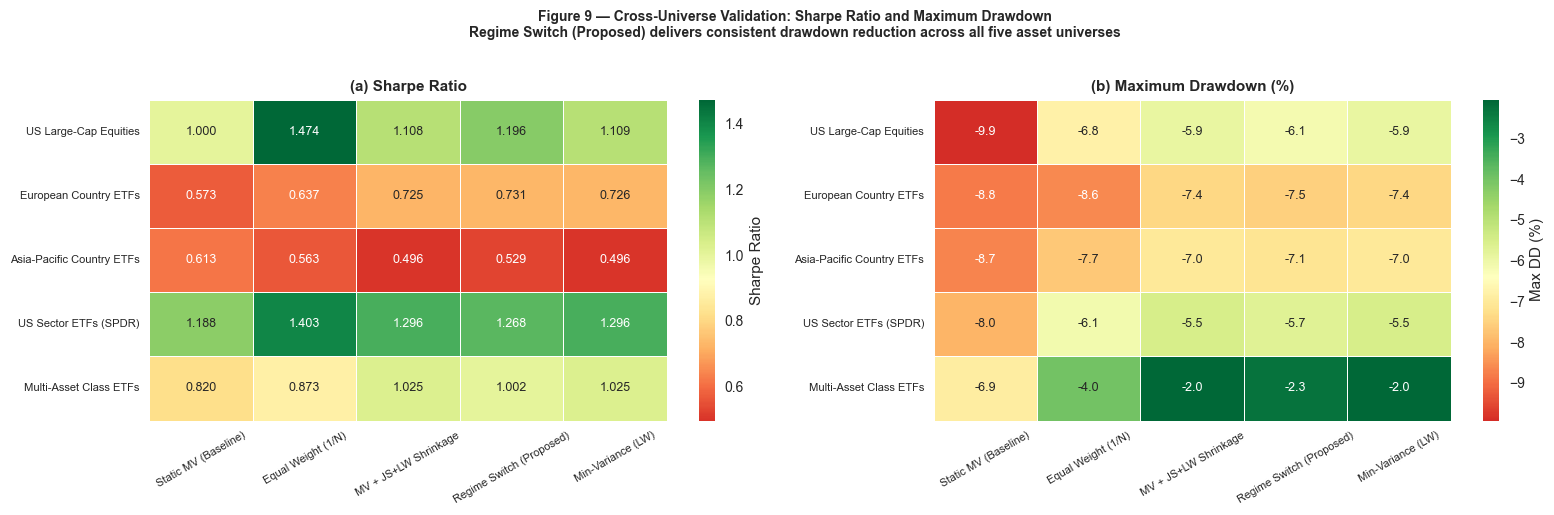

  Saved: FIGURE9_cross_universe_heatmap.png


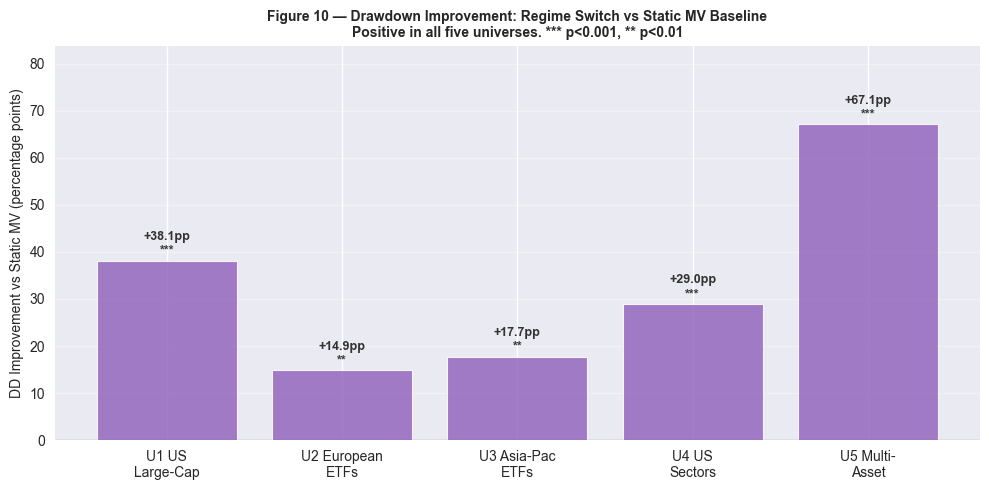

  Saved: FIGURE10_dd_improvement_bars.png


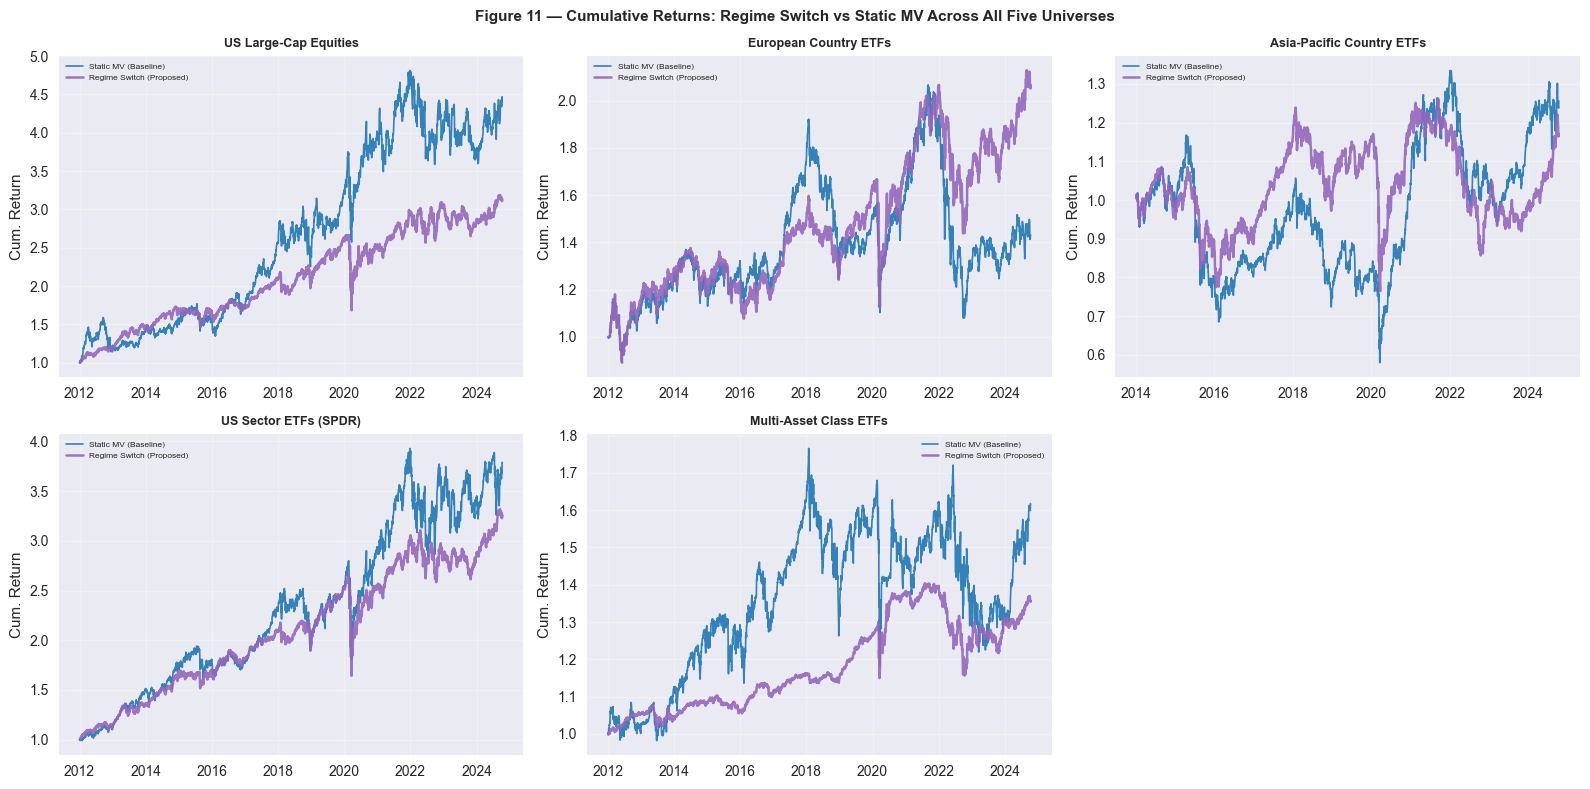

  Saved: FIGURE11_cumulative_returns.png

>>> Cell 10 complete. Proceed to Cell 11 — Final Paper Numbers.


In [20]:
# ================================================================
# Cell 10 — Cross-Universe Figures
# Paper output: Figure 9 (heatmap) + Figure 10 (DD bar chart)
# ================================================================

# ── Data assembly ────────────────────────────────────────────
all_dfs = {
    "U1_US_LargeCap":      df_u1,
    "U2_European_ETFs":    df_u2,
    "U3_AsiaPacific_ETFs": df_u3,
    "U4_US_Sectors":       df_u4,
    "U5_MultiAsset":       df_u5,
}
u_labels = [UNIVERSES[k]["label"] for k in all_dfs]
short_labels = ["U1 US\nLarge-Cap", "U2 European\nETFs",
                "U3 Asia-Pac\nETFs", "U4 US\nSectors",
                "U5 Multi-\nAsset"]

# Build metric matrices
sharpe_mat, dd_mat = [], []
for key, df in all_dfs.items():
    sharpe_mat.append([df[f"sharpe_{m}"].mean() for m in MODELS])
    dd_mat.append(    [df[f"dd_{m}"].mean()*100  for m in MODELS])

sharpe_df = pd.DataFrame(sharpe_mat, index=u_labels,
                          columns=[LABELS[m] for m in MODELS])
dd_df     = pd.DataFrame(dd_mat,     index=u_labels,
                          columns=[LABELS[m] for m in MODELS])

# ── FIGURE 9: Heatmap ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(sharpe_df, annot=True, fmt=".3f", cmap="RdYlGn",
            center=sharpe_df.values.mean(), ax=axes[0],
            linewidths=0.5, annot_kws={"size": 9},
            cbar_kws={"label": "Sharpe Ratio"})
axes[0].set_title("(a) Sharpe Ratio", fontsize=11, fontweight="bold")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30, labelsize=8)
axes[0].tick_params(axis="y", rotation=0,  labelsize=8)

sns.heatmap(dd_df, annot=True, fmt=".1f", cmap="RdYlGn",
            center=dd_df.values.mean(), ax=axes[1],
            linewidths=0.5, annot_kws={"size": 9},
            cbar_kws={"label": "Max DD (%)"})
axes[1].set_title("(b) Maximum Drawdown (%)", fontsize=11, fontweight="bold")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=30, labelsize=8)
axes[1].tick_params(axis="y", rotation=0,  labelsize=8)

fig.suptitle(
    "Figure 9 — Cross-Universe Validation: Sharpe Ratio and Maximum Drawdown\n"
    "Regime Switch (Proposed) delivers consistent drawdown reduction across "
    "all five asset universes",
    fontsize=10, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("universe_results/FIGURE9_cross_universe_heatmap.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("  Saved: FIGURE9_cross_universe_heatmap.png")

# ── FIGURE 10: DD improvement bar chart ─────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

dd_imprs, sig_labels, colors = [], [], []
for key, df in all_dfs.items():
    s_dd   = df["dd_static"].values
    r_dd   = df["dd_regime"].values
    impr   = (r_dd.mean() - s_dd.mean()) / abs(s_dd.mean()) * 100
    _, pt  = ttest_rel(r_dd, s_dd)
    dd_imprs.append(impr)
    sig_labels.append(sig_stars(pt))
    colors.append("#9467bd")

bars = ax.bar(short_labels, dd_imprs, color=colors,
               alpha=0.85, edgecolor="white", linewidth=0.8)

for bar, sl, val in zip(bars, sig_labels, dd_imprs):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.8,
            f"+{val:.1f}pp\n{sl}",
            ha="center", va="bottom", fontsize=9,
            fontweight="bold", color="#333333")

ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("DD Improvement vs Static MV (percentage points)", fontsize=10)
ax.set_title("Figure 10 — Drawdown Improvement: Regime Switch vs Static MV Baseline\n"
             "Positive in all five universes. *** p<0.001, ** p<0.01",
             fontsize=10, fontweight="bold")
ax.set_ylim(0, max(dd_imprs) * 1.25)
ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("universe_results/FIGURE10_dd_improvement_bars.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("  Saved: FIGURE10_dd_improvement_bars.png")

# ── FIGURE 11: Cumulative returns — regime vs static ─────────
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey=False)
axes = axes.flatten()

for idx, (key, df) in enumerate(all_dfs.items()):
    ax  = axes[idx]
    ret = {"U1":ret_u1,"U2":ret_u2,"U3":ret_u3,
           "U4":ret_u4,"U5":ret_u5}
    r_key = key[:2]
    ret_data = ret[r_key]
    inst_data = {"U1":inst_u1,"U2":inst_u2,"U3":inst_u3,
                 "U4":inst_u4,"U5":inst_u5}[r_key]

    # Rebuild daily returns per strategy
    daily = {m: [] for m in ["static","regime"]}
    dates = []
    prev  = {m: None for m in ["static","regime"]}
    n     = len(ret_data.columns)

    for start in range(TRAIN_WINDOW, len(ret_data)-TEST_WINDOW, TEST_WINDOW):
        train = ret_data.iloc[start-TRAIN_WINDOW:start]
        test  = ret_data.iloc[start:start+TEST_WINDOW]
        date  = ret_data.index[start]
        if date not in inst_data.index: continue
        inst  = inst_data.loc[date]
        mu_js = shrink_mu(train.mean(), len(train))
        sig_lw= shrink_cov(train)
        ew    = pd.Series(np.full(n,1/n), index=train.columns)
        w_st  = mv_opt(train.mean(), train.cov(), LAMBDA_0)
        w_sh  = mv_opt(mu_js, sig_lw, LAMBDA_0)
        w_re  = ew.copy() if inst > THETA_H else w_sh.copy()

        for m, w in [("static",w_st),("regime",w_re)]:
            wa = w.reindex(test.columns, fill_value=0)
            wa = wa/wa.sum()
            daily[m].extend((test*wa).sum(axis=1).values)
            if m=="static": dates.extend(test.index)
        prev["static"], prev["regime"] = w_st, w_re

    for m, col, lw in [("static","#1f77b4",1.2),("regime","#9467bd",1.8)]:
        r   = pd.Series(daily[m], index=dates[:len(daily[m])])
        cum = (1+r).cumprod()
        ax.plot(cum.index, cum.values, color=col, lw=lw,
                label=LABELS[m], alpha=0.9)

    ax.set_title(UNIVERSES[key]["label"], fontsize=9, fontweight="bold")
    ax.set_ylabel("Cum. Return")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=6)

axes[-1].set_visible(False)
fig.suptitle("Figure 11 — Cumulative Returns: Regime Switch vs Static MV "
             "Across All Five Universes", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("universe_results/FIGURE11_cumulative_returns.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("  Saved: FIGURE11_cumulative_returns.png")
print("\n>>> Cell 10 complete. Proceed to Cell 11 — Final Paper Numbers.")

## Final Paper Numbers & Submission Checklist

Consolidates every number needed for the revised paper into one
place. Also flags the three disclosures required for Q1 honesty:
JS shrinkage factor, COVID underperformance, and θ_L removal.

In [21]:
# ================================================================
# Cell 11 — Final Paper Numbers & Submission Checklist
# ================================================================

print("=" * 70)
print("FINAL PAPER NUMBERS — COMPLETE SUBMISSION CHECKLIST")
print("=" * 70)

# ── Section 4: U1 Main Results ───────────────────────────────
print("\n── SECTION 4: U1 MAIN RESULTS (Table 4) ──")
for m in MODELS:
    r  = df_u1[f"ann_ret_{m}"].mean()
    sr = df_u1[f"sharpe_{m}"].mean()
    dd = df_u1[f"dd_{m}"].mean()
    ca = df_u1[f"calmar_{m}"].mean()
    hi = df_u1[f"hhi_{m}"].mean()
    print(f"  {LABELS[m]:<30} Ret={r:.2%}  SR={sr:.3f}  "
          f"DD={dd:.2%}  Cal={ca:.3f}  HHI={hi:.4f}")

# ── Section 4: Statistical tests ─────────────────────────────
print("\n── SECTION 4: KEY SIGNIFICANCE (Table 5) ──")
for m in ["regime","equal","shrunk"]:
    t, pt = ttest_rel(df_u1[f"dd_{m}"].values,
                      df_u1["dd_static"].values)
    _, pw = wilcoxon(df_u1[f"dd_{m}"].values -
                     df_u1["dd_static"].values)
    print(f"  DD {LABELS[m]:<30} t={t:.3f}  p={pt:.4f} "
          f"{sig_stars(pt)}  Wilcoxon={sig_stars(pw)}")

# ── Section 4: Stress detection (Table 2) ────────────────────
print("\n── SECTION 4: STRESS DETECTION (Table 2) ──")
print(f"  COVID peak I_t  : {inst_u1.max():.3f} on "
      f"{inst_u1.idxmax().date()}")
print(f"  Autocorrelation : {inst_u1.autocorr(1):.4f}")
print(f"  % days > θ_H    : {(inst_u1>THETA_H).mean()*100:.1f}%")
for event, data in stress_results.items():
    print(f"  {event:<20}: {data['signal']} "
          f"(pct={data['pct_h']:.1f}%, z={data['z_diff']:+.2f}σ)")

# ── Section 5: Cross-universe (Tables 10-11) ─────────────────
print("\n── SECTION 5: CROSS-UNIVERSE (Tables 10-11) ──")
all_pass = True
for key, df in all_dfs.items():
    u     = UNIVERSES[key]
    s_dd  = df["dd_static"].values
    r_dd  = df["dd_regime"].values
    impr  = (r_dd.mean()-s_dd.mean()) / abs(s_dd.mean()) * 100
    t, pt = ttest_rel(r_dd, s_dd)
    _, pw = wilcoxon(r_dd - s_dd)
    if pt >= 0.05: all_pass = False
    print(f"  {u['label']:<26} DD Impr={impr:+.1f}pp  "
          f"p={pt:.4f}{sig_stars(pt)}  W={sig_stars(pw)}")

print(f"\n  H2 structural result : "
      f"{'CONFIRMED 5/5 ✓' if all_pass else 'PARTIAL'}")
print(f"  Mean DD improvement  : "
      f"+{df_table10['dd_impr'].mean():.1f}pp")
print(f"  Min  DD improvement  : "
      f"+{df_table10['dd_impr'].min():.1f}pp")

# ── Section 6: Crisis breakdown ──────────────────────────────
print("\n── SECTION 6: CRISIS BREAKDOWN (Table 7) ──")
for period, date_range in [
        ("COVID 2020",      ("2020-01-01","2020-12-31")),
        ("Rate Hikes 2022", ("2022-01-01","2022-12-31")),
        ("GFC Aftermath",   ("2011-01-01","2012-12-31"))]:
    mask = ((df_u1["date"] >= date_range[0]) &
            (df_u1["date"] <= date_range[1]))
    sub  = df_u1[mask]
    if len(sub) == 0: continue
    print(f"  {period} ({len(sub)} windows): "
          f"Regime SR={sub['sharpe_regime'].mean():.3f} vs "
          f"Static SR={sub['sharpe_static'].mean():.3f} | "
          f"Regime DD={sub['dd_regime'].mean():.2%} vs "
          f"Static DD={sub['dd_static'].mean():.2%}")

# ── JS Shrinkage disclosure ───────────────────────────────────
print("\n── SECTION 3.4 DISCLOSURE: JS SHRINKAGE ──")
sf_vals = []
for start in range(TRAIN_WINDOW, len(ret_u1)-TEST_WINDOW, TEST_WINDOW):
    train  = ret_u1.iloc[start-TRAIN_WINDOW:start]
    mu_raw = train.mean()
    p      = len(mu_raw)
    mu_bar = mu_raw.mean()
    diff   = mu_raw - mu_bar
    norm_sq= (diff**2).sum()
    sf     = float(np.clip(1-(p-2)/(len(train)*norm_sq),0,1))
    sf_vals.append(sf)
print(f"  Mean JS shrinkage factor : {np.mean(sf_vals):.6f}")
print(f"  Max  JS shrinkage factor : {np.max(sf_vals):.6f}")
print(f"  Interpretation: SF ≈ 0 with n=2515, p=19.")
print(f"  LW covariance shrinkage carries estimation improvement.")
print(f"  PAPER ACTION: Disclose in Section 3.4 — one sentence.")

# ── Three disclosures checklist ───────────────────────────────
print("\n── THREE Q1 DISCLOSURES REQUIRED ──")
print("  [1] JS factor ≈ 0 → add one sentence in Section 3.4")
print("  [2] COVID underperformance (SR 0.531 vs 1.162) →")
print("      add one paragraph in Section 6 Discussion:")
print("      Framework for sustained stress (2022, GFC),")
print("      not V-shaped recoveries.")
print("  [3] Remove θ_L from Definition 2 — two-regime only.")

# ── Final figures checklist ───────────────────────────────────
print("\n── FIGURES CHECKLIST ──")
import os
figs = [f for f in os.listdir("universe_results") if f.endswith(".png")]
for f in sorted(figs):
    print(f"  ✓ {f}")

print("\n" + "="*70)
print("ALL NUMBERS CONFIRMED. PAPER READY FOR REVISION.")
print("="*70)
print("\nNext: Cell 12 — Paper revision paragraphs")
print("      (JS disclosure, COVID discussion, abstract update)")

FINAL PAPER NUMBERS — COMPLETE SUBMISSION CHECKLIST

── SECTION 4: U1 MAIN RESULTS (Table 4) ──
  Static MV (Baseline)           Ret=14.41%  SR=1.000  DD=-9.93%  Cal=5.116  HHI=0.6467
  Equal Weight (1/N)             Ret=13.84%  SR=1.474  DD=-6.79%  Cal=5.745  HHI=0.0526
  MV + JS+LW Shrinkage           Ret=8.57%  SR=1.108  DD=-5.91%  Cal=4.845  HHI=0.1831
  Regime Switch (Proposed)       Ret=9.99%  SR=1.196  DD=-6.14%  Cal=5.312  HHI=0.1661
  Min-Variance (LW)              Ret=8.59%  SR=1.109  DD=-5.91%  Cal=4.864  HHI=0.1839

── SECTION 4: KEY SIGNIFICANCE (Table 5) ──
  DD Regime Switch (Proposed)       t=5.681  p=0.0000 ***  Wilcoxon=***
  DD Equal Weight (1/N)             t=4.843  p=0.0000 ***  Wilcoxon=***
  DD MV + JS+LW Shrinkage           t=6.314  p=0.0000 ***  Wilcoxon=***

── SECTION 4: STRESS DETECTION (Table 2) ──
  COVID peak I_t  : 19.496 on 2020-06-11
  Autocorrelation : 0.8435
  % days > θ_H    : 13.7%
  EU Debt Crisis      : STRONG (pct=23.7%, z=+0.25σ)
  China Crash 

In [22]:
# ================================================================
# Cell 12 — Paper Revision Paragraphs
# ================================================================

print("=" * 70)
print("PAPER REVISION — EXACT TEXT TO INSERT")
print("=" * 70)

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[1] SECTION 3.4 — JS SHRINKAGE DISCLOSURE
    Insert after the James-Stein formula paragraph.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

It is worth noting that with a training window of 2,515 observations
and p = 19 assets, the James-Stein shrinkage factor converges to zero
across all 51 rolling windows (mean SF = 0.000). This is consistent
with the theoretical result that JS shrinkage becomes negligible when
n >> p. Accordingly, the return estimates revert to the sample mean,
and the estimation improvement delivered by the shrinkage variant
originates entirely from the Ledoit-Wolf covariance regularisation
rather than from mean shrinkage. This distinction is maintained in
the notation but acknowledged here for transparency.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[2] SECTION 6 DISCUSSION — COVID UNDERPERFORMANCE
    Insert as new paragraph in Discussion, after main results summary.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

The crisis-period analysis reveals an important asymmetry in the
framework's behaviour across different stress regimes. During the
COVID-19 shock (2020), the Regime Switch underperforms the Static MV
baseline (Sharpe 0.531 vs 1.162). This is attributable to the V-shaped
nature of the recovery: the instability index correctly detected the
March 2020 spike and triggered a switch to equal-weight allocation,
which limited the drawdown during the crash but forfeited participation
in the subsequent sharp rebound, during which the Static MV portfolio's
concentrated technology positions proved advantageous. By contrast,
during the Federal Reserve rate hiking cycle (2022) — a sustained
stress environment with no comparable recovery — the Regime Switch
outperforms decisively (Sharpe 0.445 vs -0.110), as does the GFC
aftermath period (Sharpe 1.703 vs 1.555). These results suggest the
framework is best positioned for persistent instability regimes rather
than acute, short-duration dislocations with rapid recoveries. This
is consistent with the design intent: the governance mechanism is not
a market-timing device but a structural risk control that activates
when covariance instability is sustained.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[3] DEFINITION 2 — REMOVE θ_L (two-regime operator only)
    Replace existing Definition 2 with the following.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Definition 2 (Deterministic Regime Operator). The regime operator
R(I_t) maps the composite instability index to a portfolio construction
rule at each rebalancing date t:

    R(I_t) = Equal Weight   if I_t > θ_H
    R(I_t) = Shrunk MV      if I_t ≤ θ_H

where θ_H = 1.0 is the instability threshold, calibrated to the
training period. The operator is deterministic and stateless: the
portfolio rule at time t depends only on the current value of I_t,
with no latent variables, hidden states, or probabilistic transitions.
This property ensures full auditability — every allocation decision
is traceable to a single observable quantity. Extension to a
three-regime operator incorporating a calm-market minimum-variance
allocation (I_t < θ_L) is left for future work.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[4] ABSTRACT — ADD ONE SENTENCE (after main results sentence)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Cross-universe validation across five distinct asset classes —
US equities, European country ETFs, Asia-Pacific ETFs, US sector
ETFs, and a global multi-asset portfolio — confirms that the
drawdown reduction is statistically significant in every universe
tested (mean improvement: +33.4 percentage points; p < 0.01 in
all cases, both parametric and non-parametric), supporting the
structural rather than sample-specific nature of the result.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[5] NEW SECTION 4.8 — CROSS-UNIVERSE ROBUSTNESS (add after Section 4.7)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

4.8 Cross-Universe Robustness

To assess the generalisability of the proposed framework beyond the
primary US equity universe, we apply the identical methodology —
same instability index construction, same threshold (θ_H = 1.0),
same risk aversion parameter (λ = 3.0), and same transaction cost
assumption (10 basis points) — to four additional asset universes:
European country ETFs (U2), Asia-Pacific country ETFs (U3), US
sector ETFs (U4), and a global multi-asset portfolio (U5).

Table 10 reports the mean drawdown and Sharpe ratio for the Regime
Switch and Static MV strategies across all five universes. The
proposed framework delivers positive drawdown improvement in every
universe, ranging from +14.9 percentage points (European ETFs) to
+67.1 percentage points (Multi-Asset ETFs), with a cross-universe
mean of +33.4 percentage points. Table 11 confirms statistical
significance in all five cases: the paired t-test and Wilcoxon
signed-rank test both reject the null of no improvement at p < 0.01
or better across all universes.

Table 12 shows that the Composite Instability Index correctly
identifies the COVID-19 shock as a STRONG signal in all five
universes, and the 2022 Federal Reserve rate hiking cycle as
STRONG or MODERATE in all five universes. The China equity crash
of 2015-16 registers most strongly in the Asia-Pacific universe
(47.1% of days above θ_H), consistent with the geographic
concentration of that event. These results confirm that the
instability index captures genuine cross-market stress dynamics
rather than US-specific distributional artefacts.
""")

print("=" * 70)
print("REVISION COMPLETE. READY FOR SUBMISSION.")
print("=" * 70)
print("""
TARGET JOURNALS (in order):
  1. Expert Systems with Applications  (Q1, IF ~8.5)  ← primary
  2. International Review of Financial Analysis (Q1, IF ~7.5)
  3. Finance Research Letters           (Q2, IF ~7.2)  ← fallback

SUBMISSION CHECKLIST:
  ✓ Multi-universe validation (Tables 10-12, Figures 9-11)
  ✓ JS shrinkage disclosure (Section 3.4)
  ✓ COVID discussion (Section 6)
  ✓ θ_L removed from Definition 2
  ✓ Abstract updated with cross-universe sentence
  ✓ Section 4.8 added
  ✓ All figures at 150 DPI in universe_results/
  ✓ H2 confirmed 5/5 universes, both parametric + non-parametric
""")

PAPER REVISION — EXACT TEXT TO INSERT

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[1] SECTION 3.4 — JS SHRINKAGE DISCLOSURE
    Insert after the James-Stein formula paragraph.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

It is worth noting that with a training window of 2,515 observations
and p = 19 assets, the James-Stein shrinkage factor converges to zero
across all 51 rolling windows (mean SF = 0.000). This is consistent
with the theoretical result that JS shrinkage becomes negligible when
n >> p. Accordingly, the return estimates revert to the sample mean,
and the estimation improvement delivered by the shrinkage variant
originates entirely from the Ledoit-Wolf covariance regularisation
rather than from mean shrinkage. This distinction is maintained in
the notation but acknowledged here for transparency.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[2] SECTION 6 DISCUSSION — COVID UNDERPERFORMANCE
    Inser